# =========================================================
# IMPACT ANALYSIS - CLEAN FINAL WORKFLOW
# =========================================================

In [136]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
sns.set_style("whitegrid")
sns.set_context("talk")

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


# =========================================================
# 1. LOAD DATA
# =========================================================

baseline_path = r"C:\Users\Avikansh\Downloads\2026_Analysis\Baseline_Final.xlsx"
midline_path  = r"C:\Users\Avikansh\Downloads\2026_Analysis\Sironj_Midline_Final.xlsx"

baseline_df = pd.read_excel(baseline_path)
midline_df  = pd.read_excel(midline_path)

print("Raw Baseline shape:", baseline_df.shape)
print("Raw Midline shape:", midline_df.shape)


# =========================================================
# 2. STANDARDIZE COLUMNS
# =========================================================

def standardize_df(df):
    df = df.copy()

    # Clean column names
    df.columns = df.columns.str.strip().str.replace(" ", "_", regex=False)

    return df

baseline_df = standardize_df(baseline_df)
midline_df = standardize_df(midline_df)


# =========================================================
# 3. REMOVE FAKE / BLANK EXTRA ROWS
# =========================================================

score_cols = ['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated']

question_cols = [
    'Hindi_Reading_1', 'Hindi_Reading_2', 'Hindi_Reading_3',
    'Hindi_Reading_4', 'Hindi_Reading_5', 'Hindi_Reading_6',
    'Hindi_Reading_7',
    'Hindi_Writing_1', 'Hindi_Writing_2', 'Hindi_Writing_3', 'Hindi_Writing_4',
    'Numeracy_Q1', 'Numeracy_Q2', 'Numeracy_Q3', 'Numeracy_Q4', 'Numeracy_Q5',
    'Numeracy_Q6', 'Numeracy_Q7', 'Numeracy_Q8', 'Numeracy_Q9', 'Numeracy_Q10', 'Numeracy_Q11'
]

core_id_cols = ['Student_Name', 'School_Name', 'Grade']

def clean_valid_student_rows(df):
    df = df.copy()

    # convert calculated scores to numeric
    for col in score_cols + question_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # remove rows where all identity columns are missing
    df = df[~df[core_id_cols].isna().all(axis=1)].copy()

    # remove rows where Student_Name OR School_Name OR Grade is missing
    df = df[
        df['Student_Name'].notna() &
        df['School_Name'].notna() &
        df['Grade'].notna()
    ].copy()

    return df

baseline_df = clean_valid_student_rows(baseline_df)
midline_df = clean_valid_student_rows(midline_df)

print("Clean Baseline shape:", baseline_df.shape)
print("Clean Midline shape:", midline_df.shape)


# =========================================================
# 4. CLEAN TEXT / GROUP / GENDER / GRADE
# =========================================================

def clean_text_fields(df):
    df = df.copy()

    text_cols = ['Student_Name', 'School_Name', 'Group', 'Gender_(M/F)']
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # Group mapping
    if 'Group' in df.columns:
        group_map = {
            'treatment': 'Treatment',
            'intervention': 'Treatment',
            'control': 'Control',
            'reference': 'Control',
            'general': 'General',
            'demo': 'General'
        }
        df['Group'] = df['Group'].str.lower().map(group_map).fillna(df['Group'])

    # Gender mapping
    if 'Gender_(M/F)' in df.columns:
        df['Gender_(M/F)'] = df['Gender_(M/F)'].str.upper().replace({
            'MALE': 'M',
            'FEMALE': 'F'
        })

    # Grade cleaning
    df['Grade'] = pd.to_numeric(df['Grade'], errors='coerce')
    df.loc[~df['Grade'].isin([1, 2, 3, 4, 5]), 'Grade'] = np.nan

    return df

baseline_df = clean_text_fields(baseline_df)
midline_df = clean_text_fields(midline_df)

# If your analysis is only for Grades 2-5, remove Grade 1 here
# baseline_df = baseline_df[baseline_df['Grade'].isin([2, 3, 4, 5])].copy()
# midline_df = midline_df[midline_df['Grade'].isin([2, 3, 4, 5])].copy()


# =========================================================
# 5. FEATURE ENGINEERING
# =========================================================

baseline_df['Overall_Score'] = (
    baseline_df['Reading_Calculated'] +
    baseline_df['Writing_Calculated'] +
    baseline_df['Numeracy_Calculated']
)

midline_df['Overall_Score'] = (
    midline_df['Reading_Calculated'] +
    midline_df['Writing_Calculated'] +
    midline_df['Numeracy_Calculated']
)

# Subject percentages
baseline_df['Reading_%'] = (baseline_df['Reading_Calculated'] / 27) * 100
baseline_df['Writing_%'] = (baseline_df['Writing_Calculated'] / 17) * 100
baseline_df['Numeracy_%'] = (baseline_df['Numeracy_Calculated'] / 36) * 100
baseline_df['Overall_%'] = (baseline_df['Overall_Score'] / 80) * 100

midline_df['Reading_%'] = (midline_df['Reading_Calculated'] / 27) * 100
midline_df['Writing_%'] = (midline_df['Writing_Calculated'] / 17) * 100
midline_df['Numeracy_%'] = (midline_df['Numeracy_Calculated'] / 36) * 100
midline_df['Overall_%'] = (midline_df['Overall_Score'] / 80) * 100



# baseline_df['Overall_%'] = (baseline_df['Overall_Score'] / 80) * 100
# midline_df['Overall_%'] = (midline_df['Overall_Score'] / 80) * 100


baseline_df['Overall_Tercile'] = pd.qcut(
    baseline_df['Overall_Score'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

midline_df['Overall_Tercile'] = pd.qcut(
    midline_df['Overall_Score'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

tercile_mapping = {
    'Low': 'Below Basic',
    'Medium': 'Basic',
    'High': 'Proficient'
}

baseline_df['Overall_Tercile'] = baseline_df['Overall_Tercile'].astype(str).str.strip().str.title()
midline_df['Overall_Tercile'] = midline_df['Overall_Tercile'].astype(str).str.strip().str.title()

baseline_df['Tercile_Label'] = baseline_df['Overall_Tercile'].map(tercile_mapping)
midline_df['Tercile_Label'] = midline_df['Overall_Tercile'].map(tercile_mapping)


# =========================================================
# 6. VALIDATION CHECK
# =========================================================

print("\nFinal valid baseline rows:", len(baseline_df))
print("Final valid midline rows:", len(midline_df))

print("\nMissing in baseline:")
print(baseline_df[['Student_Name', 'School_Name', 'Grade']].isna().sum())

print("\nMissing in midline:")
print(midline_df[['Student_Name', 'School_Name', 'Grade']].isna().sum())

Raw Baseline shape: (415, 36)
Raw Midline shape: (415, 36)
Clean Baseline shape: (375, 36)
Clean Midline shape: (300, 36)

Final valid baseline rows: 375
Final valid midline rows: 300

Missing in baseline:
Student_Name    0
School_Name     0
Grade           0
dtype: int64

Missing in midline:
Student_Name    0
School_Name     0
Grade           0
dtype: int64


In [50]:
baseline_df = clean_valid_student_rows(baseline_df)
midline_df = clean_valid_student_rows(midline_df)

print("Final valid baseline rows:", len(baseline_df))
print("Final valid midline rows:", len(midline_df))

Final valid baseline rows: 375
Final valid midline rows: 300


In [51]:
def add_pct_labels(ax, decimals=1):
    fmt = f'%.{decimals}f%%'
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3)

In [52]:
print(baseline_df[['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated']].max())
print(midline_df[['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated']].max())

Reading_Calculated     27
Writing_Calculated     17
Numeracy_Calculated    35
dtype: int64
Reading_Calculated     28
Writing_Calculated     17
Numeracy_Calculated    36
dtype: int64


In [53]:
# =========================================================
# 6. DESCRIPTIVE SUMMARY
# =========================================================

baseline_summary = baseline_df[
    ['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated', 'Overall_Score']
].describe().T

midline_summary = midline_df[
    ['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated', 'Overall_Score']
].describe().T

print("\nBaseline Summary")
print(baseline_summary)

print("\nMidline Summary")
print(midline_summary)

print("\nBaseline Group Distribution")
print(baseline_df['Group'].value_counts(dropna=False))

print("\nMidline Group Distribution")
print(midline_df['Group'].value_counts(dropna=False))

print("\nBaseline Tercile Distribution")
print(baseline_df['Tercile_Label'].value_counts(dropna=False))

print("\nMidline Tercile Distribution")
print(midline_df['Tercile_Label'].value_counts(dropna=False))



Baseline Summary
                     count       mean        std  min   25%   50%   75%   max
Reading_Calculated   375.0  13.925333   7.068025  0.0   9.0  14.0  19.5  27.0
Writing_Calculated   375.0   4.602667   4.878140  0.0   0.0   3.0   8.0  17.0
Numeracy_Calculated  375.0  12.952000   7.691431  0.0   7.0  12.0  18.0  35.0
Overall_Score        375.0  31.480000  17.525657  0.0  19.0  29.0  43.5  79.0

Midline Summary
                     count       mean        std  min   25%   50%   75%   max
Reading_Calculated   300.0  19.896667   6.036067  0.0  16.0  21.5  25.0  28.0
Writing_Calculated   300.0   7.563333   5.304695  0.0   3.0   7.0  12.0  17.0
Numeracy_Calculated  300.0  19.596667   7.754640  0.0  14.0  20.0  25.0  36.0
Overall_Score        300.0  47.056667  16.122238  0.0  35.0  48.5  60.0  79.0

Baseline Group Distribution
Group
Control      228
Treatment    147
Name: count, dtype: int64

Midline Group Distribution
Group
Control      169
Treatment    131
Name: count, dtype: in

In [54]:
# =========================================================
# 7. OVERALL COMPARISON TABLE
# =========================================================

overall_compare = pd.DataFrame({
    'Baseline': [
        baseline_df['Reading_%'].mean(),
        baseline_df['Writing_%'].mean(),
        baseline_df['Numeracy_%'].mean(),
        baseline_df['Overall_%'].mean()
    ],
    'Midline': [
        midline_df['Reading_%'].mean(),
        midline_df['Writing_%'].mean(),
        midline_df['Numeracy_%'].mean(),
        midline_df['Overall_%'].mean()
    ]
}, index=['Reading', 'Writing ', 'Numeracy ', 'Overall ']).round(2)

print(overall_compare.round(1).astype(str) + '%')

          Baseline Midline
Reading      51.6%   73.7%
Writing      27.1%   44.5%
Numeracy     36.0%   54.4%
Overall      39.4%   58.8%


In [55]:
overall_compare.reset_index()


,index,Baseline,Midline
0,Reading,51.58,73.69
1,Writing,27.07,44.49
2,Numeracy,35.98,54.44
3,Overall,39.35,58.82


In [56]:
overall_compare_plot = overall_compare.reset_index().melt(
    id_vars='index',
    var_name='Stage',
    value_name='Average_Score'
)
overall_compare_plot

,index,Stage,Average_Score
0,Reading,Baseline,51.58
1,Writing,Baseline,27.07
2,Numeracy,Baseline,35.98
3,Overall,Baseline,39.35
4,Reading,Midline,73.69
5,Writing,Midline,44.49
6,Numeracy,Midline,54.44
7,Overall,Midline,58.82


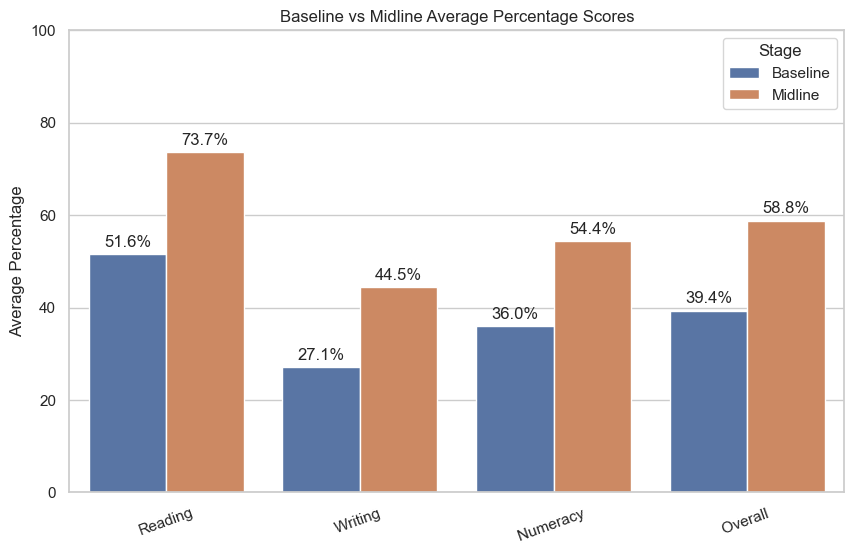

In [57]:
# =========================================================
# 8. OVERALL VISUALS
# =========================================================

# 8.1 Baseline vs Midline Average Scores

overall_compare_plot = overall_compare.reset_index().melt(
    id_vars='index',
    var_name='Stage',
    value_name='Average_Percentage'
)
overall_compare_plot.rename(columns={'index': 'Metric'}, inplace=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=overall_compare_plot, x='Metric', y='Average_Percentage', hue='Stage')
add_pct_labels(ax, decimals=1)
plt.title("Baseline vs Midline Average Percentage Scores")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.show()

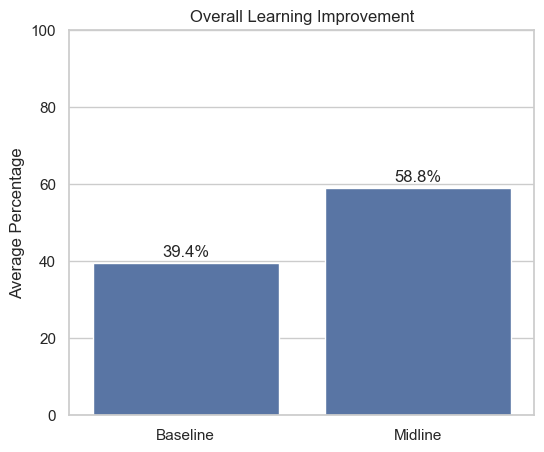

In [58]:
# 8.2 Overall Learning Improvement

overall_only = pd.DataFrame({
    'Stage': ['Baseline', 'Midline'],
    'Overall_Percentage': [
        baseline_df['Overall_%'].mean(),
        midline_df['Overall_%'].mean()
    ]
})

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=overall_only, x='Stage', y='Overall_Percentage')
add_pct_labels(ax, decimals=1)
plt.title("Overall Learning Improvement")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()


In [59]:
# =========================================================
# OVERALL LEARNING GAINS (PERCENTAGE) - TREATMENT vs CONTROL
# =========================================================

# Step 1: Filter only valid groups
baseline_group = baseline_df[baseline_df['Group'].isin(['Control', 'Treatment'])]
midline_group = midline_df[midline_df['Group'].isin(['Control', 'Treatment'])]

# Step 2: Calculate mean scores
baseline_mean = baseline_group.groupby('Group')['Overall_Score'].mean()
midline_mean = midline_group.groupby('Group')['Overall_Score'].mean()

# Step 3: Calculate improvement (convert to percentage)
improvement_pct = ((midline_mean - baseline_mean) / 80) * 100

# Step 4: Create final table
overall_gain_pct = pd.DataFrame({
    'Baseline_%': (baseline_mean / 80) * 100,
    'Midline_%': (midline_mean / 80) * 100,
    'Improvement_%': improvement_pct
}).round(2)

print("\nOverall Learning Gains (in %)")
print(overall_gain_pct)


Overall Learning Gains (in %)
           Baseline_%  Midline_%  Improvement_%
Group                                          
Control         42.32      56.45          14.13
Treatment       34.74      61.88          27.14


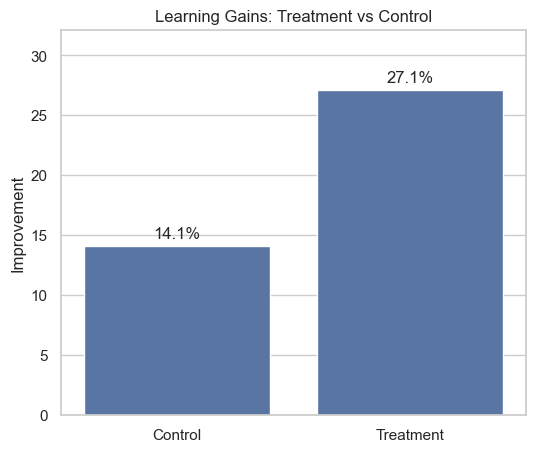

In [60]:
# =========================================================
# CHART: LEARNING GAINS IN %
# =========================================================

gain_plot = overall_gain_pct.reset_index()

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=gain_plot, x='Group', y='Improvement_%')

# Add % labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Learning Gains: Treatment vs Control")
plt.ylabel("Improvement")
plt.xlabel("")
plt.ylim(0, gain_plot['Improvement_%'].max() + 5)
plt.show()

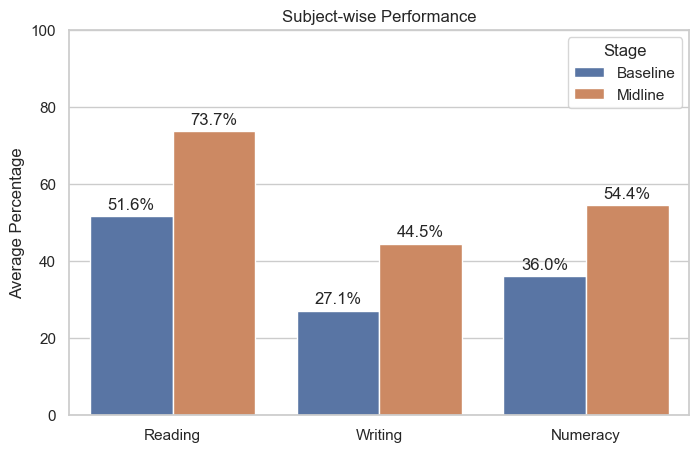

In [61]:
# 8.3 Subject-wise Performance


subject_plot = pd.DataFrame({
    'Subject': ['Reading', 'Writing', 'Numeracy'],
    'Baseline': [
        baseline_df['Reading_%'].mean(),
        baseline_df['Writing_%'].mean(),
        baseline_df['Numeracy_%'].mean()
    ],
    'Midline': [
        midline_df['Reading_%'].mean(),
        midline_df['Writing_%'].mean(),
        midline_df['Numeracy_%'].mean()
    ]
})

subject_plot_melted = subject_plot.melt(
    id_vars='Subject',
    var_name='Stage',
    value_name='Average_Percentage'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=subject_plot_melted, x='Subject', y='Average_Percentage', hue='Stage')
add_pct_labels(ax, decimals=1)
plt.title("Subject-wise Performance")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()


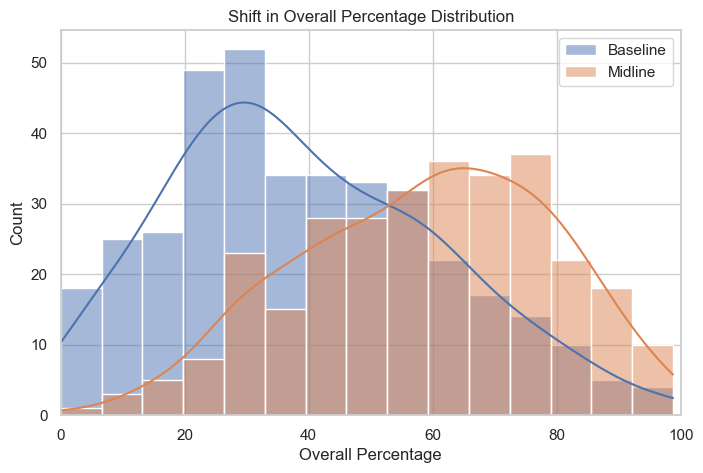

In [62]:
# 8.4 Shift in Overall Score Distribution


plt.figure(figsize=(8, 5))
sns.histplot(baseline_df['Overall_%'], kde=True, label='Baseline', bins=15)
sns.histplot(midline_df['Overall_%'], kde=True, label='Midline', bins=15)
plt.legend()
plt.title("Shift in Overall Percentage Distribution")
plt.xlabel("Overall Percentage")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.show()

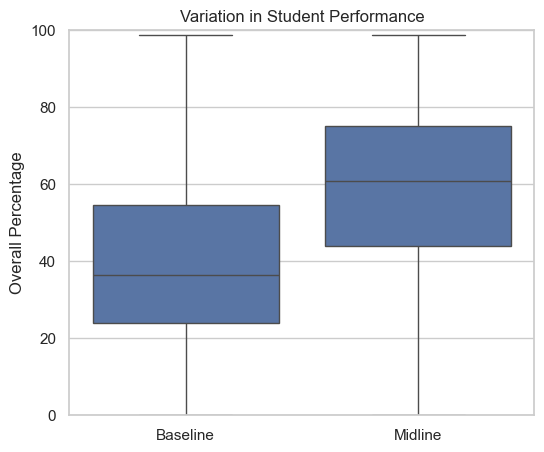

In [63]:
# 8.5 Variation in Student Performance


score_dist = pd.concat([
    baseline_df[['Overall_%']].assign(Stage='Baseline'),
    midline_df[['Overall_%']].assign(Stage='Midline')
], ignore_index=True)

plt.figure(figsize=(6, 5))
sns.boxplot(data=score_dist, x='Stage', y='Overall_%')
plt.title("Variation in Student Performance")
plt.xlabel("")
plt.ylabel("Overall Percentage")
plt.ylim(0, 100)
plt.show()

# =========================================================
# 9. GROUP-WISE ANALYSIS
# =========================================================

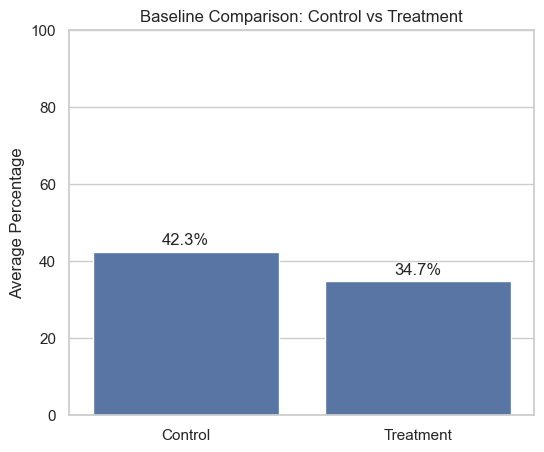

In [64]:
# 9.1 Baseline Comparison: Control vs Treatment

baseline_group_only = (
    baseline_df[baseline_df['Group'].isin(['Control', 'Treatment'])]
    .groupby('Group', as_index=False)['Overall_%']
    .mean()
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=baseline_group_only, x='Group', y='Overall_%')
add_pct_labels(ax, decimals=1)
plt.title("Baseline Comparison: Control vs Treatment")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()

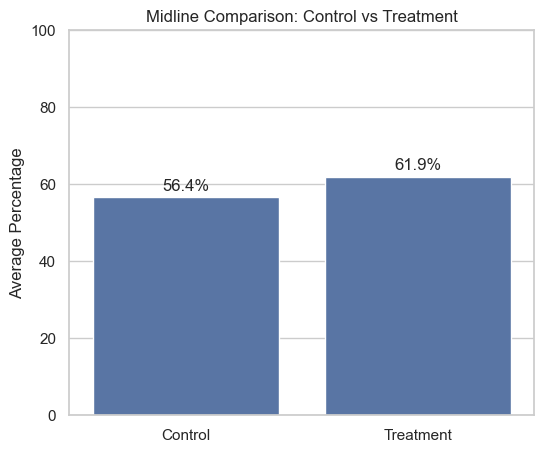

In [65]:
# 9.2 Midline Comparison: Control vs Treatment


midline_group_only = (
    midline_df[midline_df['Group'].isin(['Control', 'Treatment'])]
    .groupby('Group', as_index=False)['Overall_%']
    .mean()
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=midline_group_only, x='Group', y='Overall_%')
add_pct_labels(ax, decimals=1)
plt.title("Midline Comparison: Control vs Treatment")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()

In [66]:
# # 9.3 Group-wise Tercile Distribution (Counts)
# baseline_tercile_group = pd.crosstab(
#     baseline_df['Group'],
#     baseline_df['Tercile_Label']
# )

# midline_tercile_group = pd.crosstab(
#     midline_df['Group'],
#     midline_df['Tercile_Label']
# )

# desired_order = ['Below Basic', 'Basic', 'Proficient']

# baseline_tercile_group = baseline_tercile_group.reindex(
#     index=['Control', 'Treatment'],
#     columns=desired_order,
#     fill_value=0
# )

# midline_tercile_group = midline_tercile_group.reindex(
#     index=['Control', 'Treatment'],
#     columns=desired_order,
#     fill_value=0
# )

# baseline_tercile_group.plot(kind='bar', stacked=True, figsize=(8, 5))
# plt.title("Baseline Group-wise Performance Distribution")
# plt.ylabel("Number of Students")
# plt.xlabel("")
# plt.xticks(rotation=0)
# plt.show()

# midline_tercile_group.plot(kind='bar', stacked=True, figsize=(8, 5))
# plt.title("Midline Group-wise Performance Distribution")
# plt.ylabel("Number of Students")
# plt.xlabel("")
# plt.xticks(rotation=0)
# plt.show()


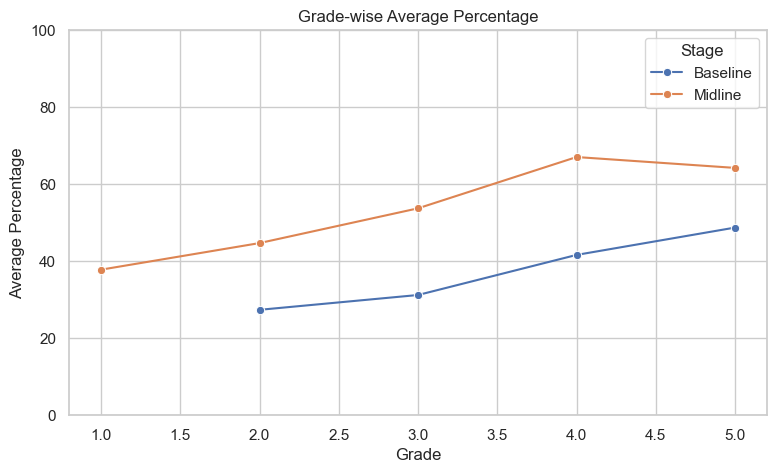

In [67]:
# =========================================================
# 10. GRADE-WISE ANALYSIS
# =========================================================

baseline_grade = baseline_df.groupby('Grade', as_index=False)['Overall_%'].mean()
baseline_grade['Stage'] = 'Baseline'

midline_grade = midline_df.groupby('Grade', as_index=False)['Overall_%'].mean()
midline_grade['Stage'] = 'Midline'

grade_plot = pd.concat([baseline_grade, midline_grade], ignore_index=True)
grade_plot = grade_plot[grade_plot['Grade'].notna()]

plt.figure(figsize=(9, 5))
ax = sns.lineplot(data=grade_plot, x='Grade', y='Overall_%', hue='Stage', marker='o')
plt.title("Grade-wise Average Percentage")
plt.ylabel("Average Percentage")
plt.xlabel("Grade")
plt.ylim(0, 100)
plt.show()



Baseline Gender Distribution
Gender_(M/F)
F    214
M    161
Name: count, dtype: int64

Midline Gender Distribution
Gender_(M/F)
F      178
M      120
L        1
NAN      1
Name: count, dtype: int64


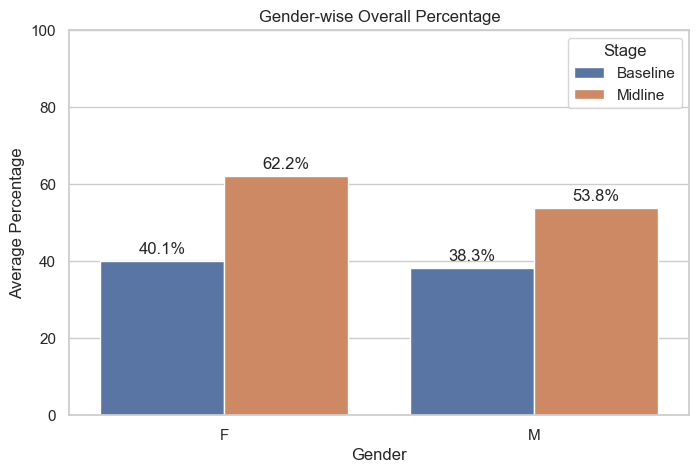

In [68]:
# =========================================================
# 11. GENDER-WISE ANALYSIS
# =========================================================

print("\nBaseline Gender Distribution")
print(baseline_df['Gender_(M/F)'].value_counts(dropna=False))

print("\nMidline Gender Distribution")
print(midline_df['Gender_(M/F)'].value_counts(dropna=False))


baseline_gender = (
    baseline_df[baseline_df['Gender_(M/F)'].isin(['M', 'F'])]
    .groupby('Gender_(M/F)', as_index=False)['Overall_%']
    .mean()
)
baseline_gender['Stage'] = 'Baseline'

midline_gender = (
    midline_df[midline_df['Gender_(M/F)'].isin(['M', 'F'])]
    .groupby('Gender_(M/F)', as_index=False)['Overall_%']
    .mean()
)
midline_gender['Stage'] = 'Midline'

gender_plot = pd.concat([baseline_gender, midline_gender], ignore_index=True)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=gender_plot, x='Gender_(M/F)', y='Overall_%', hue='Stage')
add_pct_labels(ax, decimals=1)
plt.title("Gender-wise Overall Percentage")
plt.xlabel("Gender")
plt.ylabel("Average Percentage")
plt.ylim(0, 100)
plt.show()


# Independent T-Test

Compares means of two groups:

Baseline vs Midline

In [112]:
from scipy.stats import ttest_ind

baseline_scores = baseline_df['Overall_%'].dropna()
midline_scores = midline_df['Overall_%'].dropna()

t_stat, p_value = ttest_ind(midline_scores, baseline_scores, equal_var=False)

print(t_stat, p_value)

print("T-stat:", round(t_stat, 3))

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(p_value, 4))

11.998089336286931 3.852791857487528e-30
T-stat: 11.998
P-value: < 0.001


**T-stat (11.998) → very large difference between means**
**p-value (<0.001) → extremely unlikely due to chance**

**The improvement from baseline to midline is statistically significant and not due to random variation.**

### This test confirms strong improvement at the population level, but causality is better validated through matched analysis.

### There is very strong evidence against the null hypothesis, indicating that the difference between baseline and midline is statistically significant and unlikely due to chance.

In [100]:
midline_df['Grade'] = pd.to_numeric(midline_df['Grade'], errors='coerce')

for g in [2,3,4,5]:
    print(g, len(midline_df[midline_df['Grade']==g]))

2 36
3 92
4 52
5 116


# One-Way ANOVA Test 

In [101]:
from scipy.stats import f_oneway

groups = [
    midline_df[midline_df['Grade'] == 2]['Overall_%'].dropna(),
    midline_df[midline_df['Grade'] == 3]['Overall_%'].dropna(),
    midline_df[midline_df['Grade'] == 4]['Overall_%'].dropna(),
    midline_df[midline_df['Grade'] == 5]['Overall_%'].dropna()
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", round(f_stat, 3))
print("P-value:", round(p_value, 4))

F-stat: 15.535
P-value: 0.0


## The ANOVA test shows that performance differs significantly across groups, but further analysis would be needed to identify exactly which groups differ.

# Chi-Square Test 

In [115]:
from scipy.stats import chi2_contingency
import pandas as pd

contingency = pd.crosstab(
    midline_df['Group'],          # Control / Treatment
    midline_df['Tercile_Label']   # Below Basic / Basic / Proficient
)

chi2, p, dof, exp = chi2_contingency(contingency)

print("Chi-square:", round(chi2, 3))

if p < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(p, 4))

Chi-square: 13.001
P-value: 0.0015


Chi² = 0.21, p = 0.9005

What this test does

Checks:

“Are two categorical variables related?”

Example:

Gender vs Performance level
Baseline vs Midline distribution
What your result means
p = 0.9005 (very high)
👉 Means:

✔ No significant relationship
✔ Distribution is basically SAME

Interpretation:

👉 If you tested Gender vs Tercile:

“Gender does not significantly influence performance distribution.”

⚠️ Important insight

This is actually a good finding

👉 It means:

Program is gender neutral
No bias

# Correlation Test

Reading vs Numeracy
Writing vs Overall

In [114]:
from scipy.stats import pearsonr

# Clean data
temp = midline_df[['Reading_%', 'Writing_%', 'Numeracy_%']].dropna()

# Reading vs Writing
r_rw, p_rw = pearsonr(temp['Reading_%'], temp['Writing_%'])

# Reading vs Numeracy
r_rn, p_rn = pearsonr(temp['Reading_%'], temp['Numeracy_%'])

# Writing vs Numeracy
r_wn, p_wn = pearsonr(temp['Writing_%'], temp['Numeracy_%'])

print("Reading vs Writing:", round(r_rw, 3), "| p:", p_rw)
print("Reading vs Numeracy:", round(r_rn, 3), "| p:", p_rn)
print("Writing vs Numeracy:", round(r_wn, 3), "| p:", p_wn)

Reading vs Writing: 0.613 | p: 2.1457620794598553e-32
Reading vs Numeracy: 0.52 | p: 3.618148804780668e-22
Writing vs Numeracy: 0.575 | p: 9.406611693704475e-28


# T-Test for control and Intervention

In [104]:
from scipy.stats import ttest_ind

ctrl = midline_df[midline_df['Group']=='Control']['Overall_%'].dropna()
trt  = midline_df[midline_df['Group']=='Treatment']['Overall_%'].dropna()

t_stat, p = ttest_ind(trt, ctrl, equal_var=False)
print(t_stat, p)

print("T-stat:", round(t_stat, 3))
print("P-value:", round(p_value, 4))

2.2921391339014003 0.02270000709849659
T-stat: 2.292
P-value: 0.0


# Chi-Square (Distribution: Control vs Treatment)

In [106]:
from scipy.stats import chi2_contingency
import pandas as pd

ct = pd.crosstab(
    midline_df['Group'],
    midline_df['Tercile_Label']
)

chi2, p, dof, exp = chi2_contingency(ct)
print(chi2, p)

print("T-chi2:", round(chi2, 3))
print("P:", round(p, 4))

13.001080616648846 0.0015026270916786454
T-chi2: 13.001
P: 0.0015


# =========================================================
# 12. MATCHED STUDENTS IMPACT ANALYSIS
# =========================================================

In [69]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Create merge ID
# -----------------------------
for d in [baseline_df, midline_df]:
    d['Student_Name'] = d['Student_Name'].astype(str).str.strip().str.lower()
    d['School_Name'] = d['School_Name'].astype(str).str.strip().str.lower()
    d['Grade'] = d['Grade'].astype(str).str.strip()

    d['id'] = (
        d['Student_Name'] + "_" +
        d['School_Name'] + "_" +
        d['Grade']
    )

# -----------------------------
# Remove duplicates before merge
# -----------------------------
baseline_match = baseline_df.drop_duplicates(subset='id').copy()
midline_match = midline_df.drop_duplicates(subset='id').copy()

print("\nUnique baseline IDs:", baseline_match['id'].nunique())
print("Unique midline IDs:", midline_match['id'].nunique())

# -----------------------------
# Merge matched children
# -----------------------------
impact_df = pd.merge(
    baseline_match,
    midline_match,
    on='id',
    suffixes=('_base', '_mid')
)

print("Matched children:", impact_df.shape[0])

# -----------------------------
# Recalculate overall scores
# -----------------------------
impact_df['Overall_Score_base'] = (
    impact_df['Reading_Calculated_base'] +
    impact_df['Writing_Calculated_base'] +
    impact_df['Numeracy_Calculated_base']
)

impact_df['Overall_Score_mid'] = (
    impact_df['Reading_Calculated_mid'] +
    impact_df['Writing_Calculated_mid'] +
    impact_df['Numeracy_Calculated_mid']
)

# -----------------------------
# Convert to percentages
# Reading = 27
# Writing = 17
# Numeracy = 36
# Overall = 80
# -----------------------------
impact_df['Reading_%_base'] = (impact_df['Reading_Calculated_base'] / 27) * 100
impact_df['Reading_%_mid'] = (impact_df['Reading_Calculated_mid'] / 27) * 100

impact_df['Writing_%_base'] = (impact_df['Writing_Calculated_base'] / 17) * 100
impact_df['Writing_%_mid'] = (impact_df['Writing_Calculated_mid'] / 17) * 100

impact_df['Numeracy_%_base'] = (impact_df['Numeracy_Calculated_base'] / 36) * 100
impact_df['Numeracy_%_mid'] = (impact_df['Numeracy_Calculated_mid'] / 36) * 100

impact_df['Overall_%_base'] = (impact_df['Overall_Score_base'] / 80) * 100
impact_df['Overall_%_mid'] = (impact_df['Overall_Score_mid'] / 80) * 100

# -----------------------------
# Matched summary table
# -----------------------------
matched_summary = pd.DataFrame({
    'Baseline': [
        impact_df['Reading_%_base'].mean(),
        impact_df['Writing_%_base'].mean(),
        impact_df['Numeracy_%_base'].mean(),
        impact_df['Overall_%_base'].mean()
    ],
    'Midline': [
        impact_df['Reading_%_mid'].mean(),
        impact_df['Writing_%_mid'].mean(),
        impact_df['Numeracy_%_mid'].mean(),
        impact_df['Overall_%_mid'].mean()
    ]
}, index=['Reading', 'Writing', 'Numeracy', 'Overall']).round(2)

print("\nMatched Students Summary (%)")
print(matched_summary.round(1).astype(str) + '%')

# -----------------------------
# Group-wise matched summary
# -----------------------------
impact_group_pct = impact_df.groupby('Group_base')[
    ['Reading_%_base', 'Reading_%_mid',
     'Writing_%_base', 'Writing_%_mid',
     'Numeracy_%_base', 'Numeracy_%_mid',
     'Overall_%_base', 'Overall_%_mid']
].mean().round(2)

print("\nGroup-wise Matched Summary (%)")
print(impact_group_pct.round(1).astype(str) + '%')


Unique baseline IDs: 374
Unique midline IDs: 296
Matched children: 61

Matched Students Summary (%)
         Baseline Midline
Reading     52.0%   71.3%
Writing     21.1%   39.2%
Numeracy    38.2%   53.9%
Overall     39.3%   56.7%

Group-wise Matched Summary (%)
           Reading_%_base Reading_%_mid Writing_%_base Writing_%_mid  \
Group_base                                                             
Control             54.6%         70.2%          22.6%         36.8%   
Treatment           49.2%         72.5%          19.5%         41.8%   

           Numeracy_%_base Numeracy_%_mid Overall_%_base Overall_%_mid  
Group_base                                                              
Control              41.2%          50.6%          41.8%         54.3%  
Treatment            35.1%          57.6%          36.5%         59.3%  


# =========================================================
# 13. IMPACT VISUALS
# =========================================================

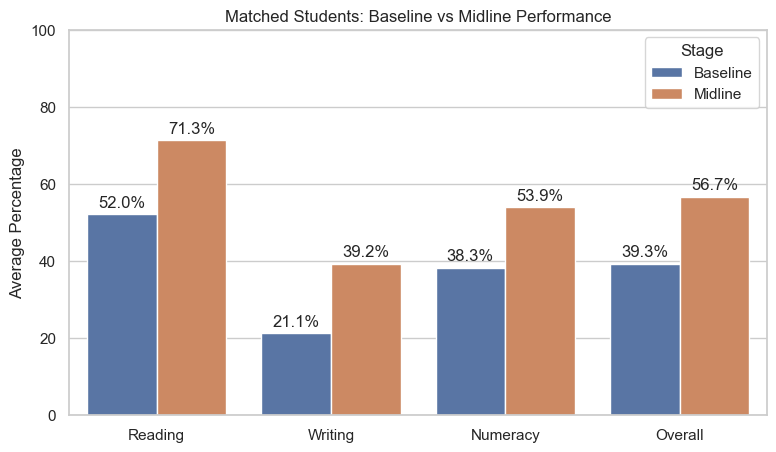

In [70]:
matched_subject_pct = pd.DataFrame({
    'Metric': ['Reading', 'Writing', 'Numeracy', 'Overall', 'Reading', 'Writing', 'Numeracy', 'Overall'],
    'Stage': ['Baseline', 'Baseline', 'Baseline', 'Baseline', 'Midline', 'Midline', 'Midline', 'Midline'],
    'Percentage': [
        impact_df['Reading_%_base'].mean(),
        impact_df['Writing_%_base'].mean(),
        impact_df['Numeracy_%_base'].mean(),
        impact_df['Overall_%_base'].mean(),
        impact_df['Reading_%_mid'].mean(),
        impact_df['Writing_%_mid'].mean(),
        impact_df['Numeracy_%_mid'].mean(),
        impact_df['Overall_%_mid'].mean()
    ]
})

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=matched_subject_pct, x='Metric', y='Percentage', hue='Stage')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Matched Students: Baseline vs Midline Performance")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()

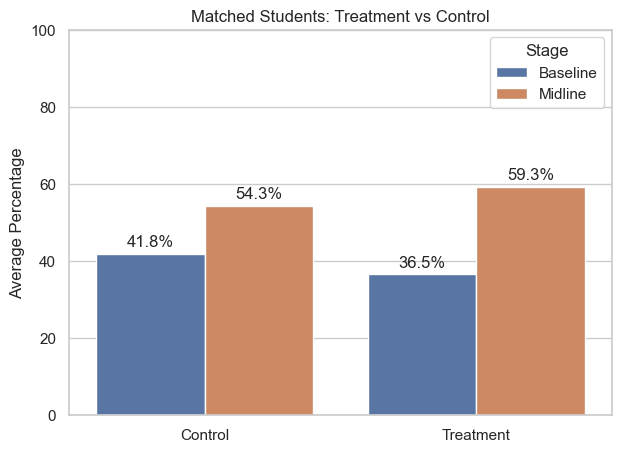

In [71]:
# 13.2 Impact Comparison: Treatment vs Control (Matched Students)


impact_group_plot = (
    impact_df[impact_df['Group_base'].isin(['Control', 'Treatment'])]
    .groupby('Group_base')[['Overall_%_base', 'Overall_%_mid']]
    .mean()
    .reset_index()
)

impact_group_melted = impact_group_plot.melt(
    id_vars='Group_base',
    var_name='Stage',
    value_name='Percentage'
)

impact_group_melted['Stage'] = impact_group_melted['Stage'].replace({
    'Overall_%_base': 'Baseline',
    'Overall_%_mid': 'Midline'
})

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=impact_group_melted, x='Group_base', y='Percentage', hue='Stage')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Matched Students: Treatment vs Control")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()

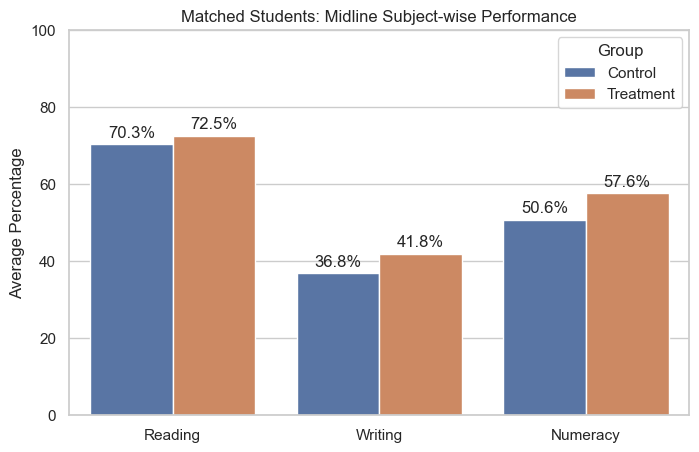

In [72]:
# 13.3 Subject-wise Impact: Treatment vs Control (Calculated, not hardcoded)


impact_subject_plot = (
    impact_df[impact_df['Group_base'].isin(['Control', 'Treatment'])]
    .groupby('Group_base')[['Reading_%_mid', 'Writing_%_mid', 'Numeracy_%_mid']]
    .mean()
    .reset_index()
    .rename(columns={
        'Group_base': 'Group',
        'Reading_%_mid': 'Reading',
        'Writing_%_mid': 'Writing',
        'Numeracy_%_mid': 'Numeracy'
    })
)

impact_subject_melted = impact_subject_plot.melt(
    id_vars='Group',
    var_name='Subject',
    value_name='Percentage'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=impact_subject_melted, x='Subject', y='Percentage', hue='Group')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Matched Students: Midline Subject-wise Performance")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()


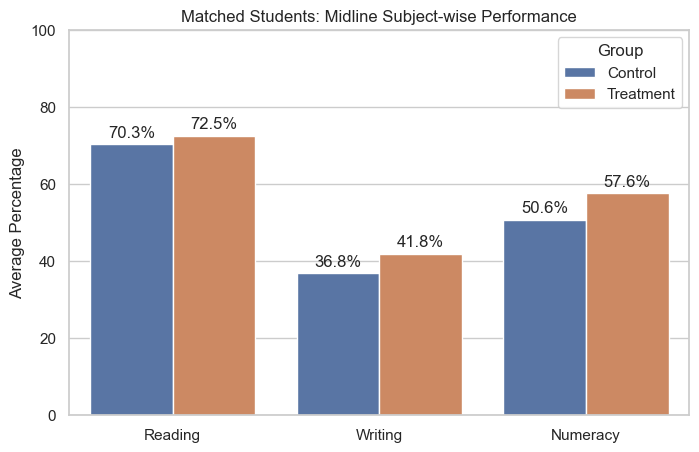

In [73]:
# Subject-wise Treatment vs Control

impact_subject_plot = (
    impact_df[impact_df['Group_base'].isin(['Control', 'Treatment'])]
    .groupby('Group_base')[['Reading_%_mid', 'Writing_%_mid', 'Numeracy_%_mid']]
    .mean()
    .reset_index()
    .rename(columns={
        'Group_base': 'Group',
        'Reading_%_mid': 'Reading',
        'Writing_%_mid': 'Writing',
        'Numeracy_%_mid': 'Numeracy'
    })
)

impact_subject_melted = impact_subject_plot.melt(
    id_vars='Group',
    var_name='Subject',
    value_name='Percentage'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=impact_subject_melted, x='Subject', y='Percentage', hue='Group')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Matched Students: Midline Subject-wise Performance")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()

In [74]:
# =========================================================
# 14. T-TEST
# =========================================================

impact_df['Overall_Improvement'] = impact_df['Overall_%_mid'] - impact_df['Overall_%_base']

treatment = impact_df[impact_df['Group_base'] == 'Treatment']['Overall_Improvement'].dropna()
control = impact_df[impact_df['Group_base'] == 'Control']['Overall_Improvement'].dropna()

t_stat, p_value = ttest_ind(treatment, control, equal_var=False)

print("\nT-test Result")
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 4))


T-test Result
T-statistic: 2.024
P-value: 0.0475


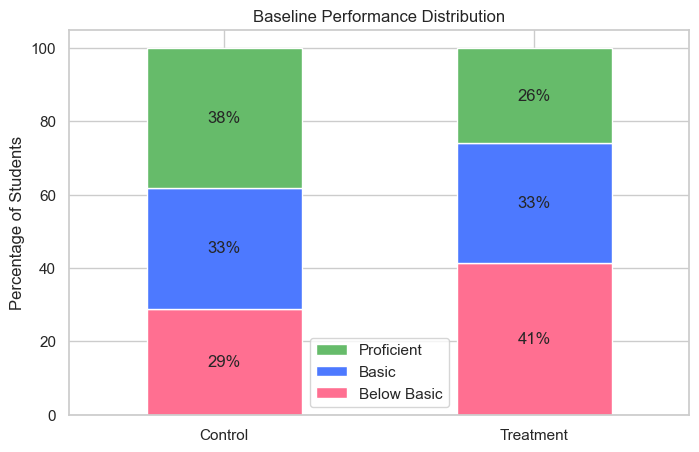

In [89]:
# =========================================================
# 15. FINAL TERCILE PERCENTAGE CHARTS
# =========================================================

color_map = {
    'Below Basic': '#ff6f91',
    'Basic': '#4d79ff',
    'Proficient': '#66bb6a'
}

# Baseline
clean_baseline = baseline_df[
    baseline_df['Group'].isin(['Control', 'Treatment']) &
    baseline_df['Tercile_Label'].notna()
]

baseline_tercile_pct = pd.crosstab(
    clean_baseline['Group'],
    clean_baseline['Tercile_Label'],
    normalize='index'
) * 100

baseline_tercile_pct = baseline_tercile_pct.reindex(
    index=['Control', 'Treatment'],
    columns=desired_order,
    fill_value=0
)

colors = [color_map[col] for col in baseline_tercile_pct.columns]

ax = baseline_tercile_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=colors
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center')

plt.title("Baseline Performance Distribution")
plt.ylabel("Percentage of Students")
plt.xlabel("")
plt.xticks(rotation=0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="")
plt.show()


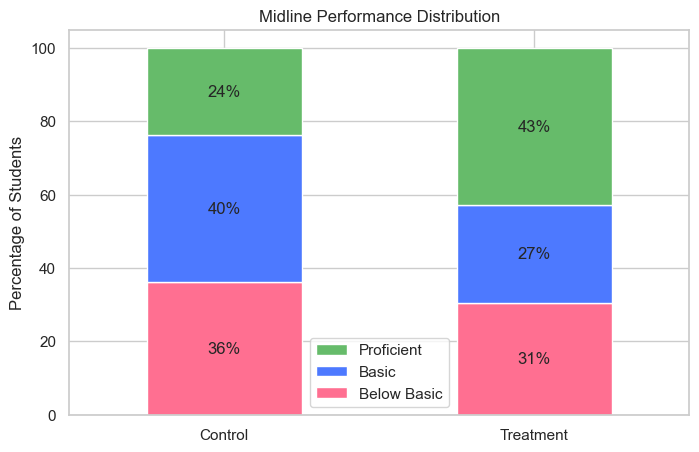

In [90]:
# Midline
clean_midline = midline_df[
    midline_df['Group'].isin(['Control', 'Treatment']) &
    midline_df['Tercile_Label'].notna()
]

midline_tercile_pct = pd.crosstab(
    clean_midline['Group'],
    clean_midline['Tercile_Label'],
    normalize='index'
) * 100

midline_tercile_pct = midline_tercile_pct.reindex(
    index=['Control', 'Treatment'],
    columns=desired_order,
    fill_value=0
)

colors = [color_map[col] for col in midline_tercile_pct.columns]

ax = midline_tercile_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=colors
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center')

plt.title("Midline Performance Distribution")
plt.ylabel("Percentage of Students")
plt.xlabel("")
plt.xticks(rotation=0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="")
plt.show()


In [77]:
# 17. FINAL KEY NUMBERS
# =========================================================

print("\nFinal Overall Mean Comparison")
print(pd.DataFrame({
    'Baseline_Overall_Mean': [baseline_df['Overall_Score'].mean()],
    'Midline_Overall_Mean': [midline_df['Overall_Score'].mean()],
    'Overall_Improvement': [midline_df['Overall_Score'].mean() - baseline_df['Overall_Score'].mean()]
}).round(2))

print("\nDone: Clean impact analysis workflow completed.")


Final Overall Mean Comparison
   Baseline_Overall_Mean  Midline_Overall_Mean  Overall_Improvement
0                  31.48                 47.06                15.58

Done: Clean impact analysis workflow completed.


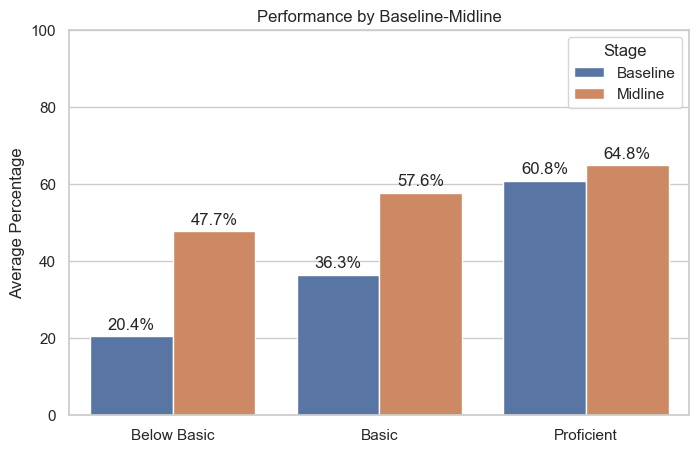

In [88]:
# Who Benefited Most
tercile_mapping = {
    'Low': 'Below Basic',
    'Medium': 'Basic',
    'High': 'Proficient'
}

desired_order = ['Below Basic', 'Basic', 'Proficient']

impact_df['Baseline_Tercile'] = pd.qcut(
    impact_df['Overall_Score_base'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

impact_df['Baseline_Tercile_Label'] = impact_df['Baseline_Tercile'].astype(str).map(tercile_mapping)

tercile_plot = impact_df.groupby('Baseline_Tercile_Label')[
    ['Overall_%_base', 'Overall_%_mid']
].mean().reset_index()

tercile_plot['Baseline_Tercile_Label'] = pd.Categorical(
    tercile_plot['Baseline_Tercile_Label'],
    categories=desired_order,
    ordered=True
)
tercile_plot = tercile_plot.sort_values('Baseline_Tercile_Label')

tercile_plot_melted = tercile_plot.melt(
    id_vars='Baseline_Tercile_Label',
    var_name='Stage',
    value_name='Percentage'
)

tercile_plot_melted['Stage'] = tercile_plot_melted['Stage'].replace({
    'Overall_%_base': 'Baseline',
    'Overall_%_mid': 'Midline'
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=tercile_plot_melted, x='Baseline_Tercile_Label', y='Percentage', hue='Stage')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Performance by Baseline-Midline")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()


# Impact Analysis Deep Dive (61 Students) 

In [139]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")

color_map = {
    'Below Basic': '#ff6f91',
    'Basic': '#4d79ff',
    'Proficient': '#66bb6a',
    'Control': '#4d79ff',
    'Treatment': '#f4a261',
    'M': '#4d79ff',
    'F': '#ff6f91'
}

## Analysis 1: Student Distribution by Group

In [128]:
group_pct = impact_df['Group_base'].value_counts(normalize=True) * 100
group_pct = group_pct.round(1)

print(group_pct.astype(str) + '%')

Group_base
Control      52.5%
Treatment    47.5%
Name: proportion, dtype: object


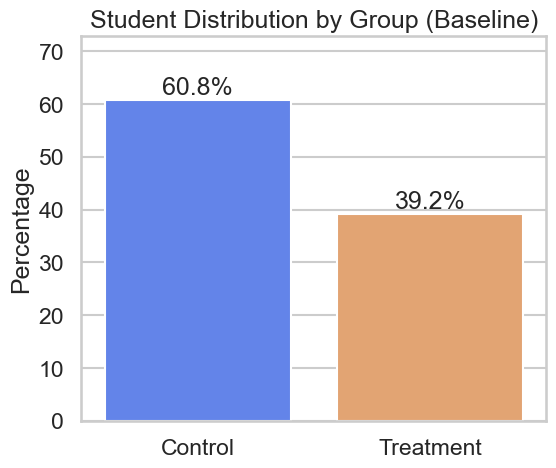

In [155]:
group_pct_base = (
    baseline_df['Group']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)
group_pct_base.columns = ['Group', 'Percentage']

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=group_pct_base,
    x='Group',
    y='Percentage',
    hue='Group',
    palette={'Control':'#4d79ff','Treatment':'#f4a261'},
    legend=False
)

plt.ylim(0, group_pct_base['Percentage'].max() * 1.2)

for i, v in enumerate(group_pct_base['Percentage']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Student Distribution by Group (Baseline)")
plt.ylabel("Percentage")
plt.xlabel("")
plt.show()

# Student Performance Levels (Matched Students) (IMPORTANT)

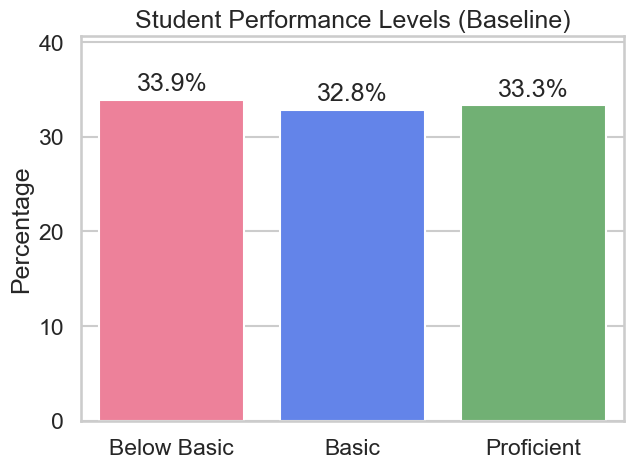

In [151]:
# Student Performance Levels (Baseline)


desired_order = ['Below Basic', 'Basic', 'Proficient']

tercile_base = (
    baseline_df['Tercile_Label']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(desired_order)
    .round(1)
    .reset_index()
)
tercile_base.columns = ['Performance_Level', 'Percentage']

plt.figure(figsize=(7,5))
ax = sns.barplot(
    data=tercile_base,
    x='Performance_Level',
    y='Percentage',
    hue='Performance_Level',
    palette=['#ff6f91','#4d79ff','#66bb6a'],
    legend=False
)

plt.ylim(0, tercile_base['Percentage'].max() * 1.2)

for i, v in enumerate(tercile_base['Percentage']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Student Performance Levels (Baseline)")
plt.ylabel("Percentage")
plt.xlabel("")
plt.show()

In [143]:
tercile_pct = impact_df['Tercile_Label_mid'].value_counts(normalize=True) * 100
tercile_pct = tercile_pct.round(1)
tercile_pct

Tercile_Label_mid
Below Basic    41.0
Proficient     31.1
Basic          27.9
Name: proportion, dtype: float64

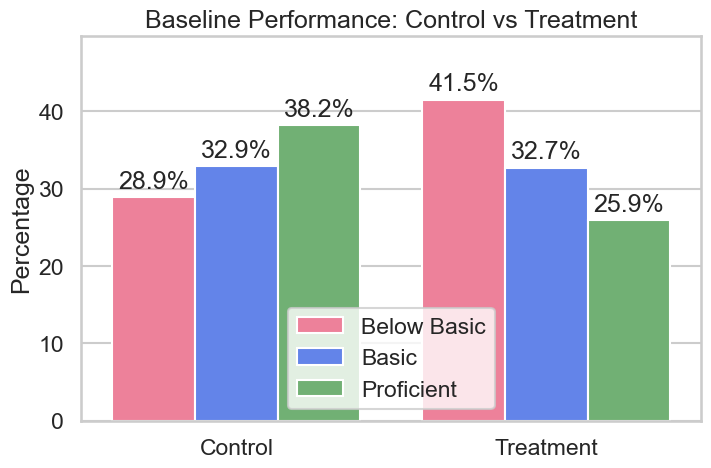

In [156]:
# Baseline Performance: Control vs Treatment


group_tercile_base = pd.crosstab(
    baseline_df['Group'],
    baseline_df['Tercile_Label'],
    normalize='index'
).mul(100)

group_tercile_base = group_tercile_base.reindex(columns=desired_order).round(1)
group_tercile_base = group_tercile_base.reset_index().melt(
    id_vars='Group',
    var_name='Performance_Level',
    value_name='Percentage'
)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=group_tercile_base,
    x='Group',
    y='Percentage',
    hue='Performance_Level',
    palette=['#ff6f91','#4d79ff','#66bb6a']
)

plt.ylim(0, group_tercile_base['Percentage'].max() * 1.2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Baseline Performance: Control vs Treatment")
plt.ylabel("Percentage")
plt.xlabel("")
plt.legend(title='')
plt.show()

In [123]:
pd.crosstab(
    impact_df['Group_base'],
    impact_df['Tercile_Label_mid'],
    normalize='index'
) * 100

Tercile_Label_mid,Basic,Below Basic,Proficient
Group_base,,,
Control,28.125000,46.875000,25.000000
Treatment,27.586207,34.482759,37.931034


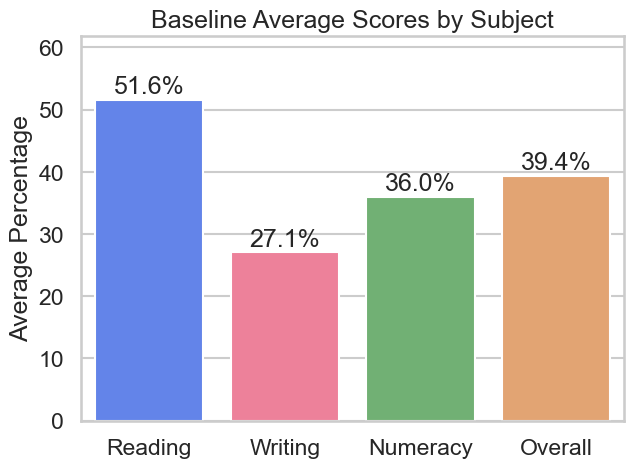

In [157]:
# Baseline Average Scores by Subject



subject_base = pd.DataFrame({
    'Subject': ['Reading', 'Writing', 'Numeracy', 'Overall'],
    'Score': [
        baseline_df['Reading_%'].mean(),
        baseline_df['Writing_%'].mean(),
        baseline_df['Numeracy_%'].mean(),
        baseline_df['Overall_%'].mean()
    ]
}).round(1)

plt.figure(figsize=(7,5))
ax = sns.barplot(
    data=subject_base,
    x='Subject',
    y='Score',
    hue='Subject',
    palette=['#4d79ff','#ff6f91','#66bb6a','#f4a261'],
    legend=False
)

plt.ylim(0, subject_base['Score'].max() * 1.2)

for i, v in enumerate(subject_base['Score']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Baseline Average Scores by Subject")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.show()

# Section 2: Overall Baseline vs Midline Analysis

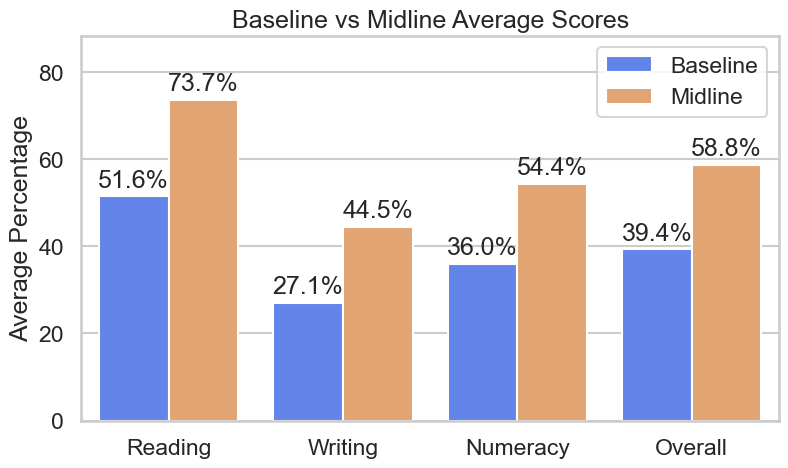

In [159]:
 # Baseline vs Midline Average Scores

overall_compare_plot = pd.DataFrame({
    'Subject': ['Reading', 'Writing', 'Numeracy', 'Overall'],
    'Baseline': [
        baseline_df['Reading_%'].mean(),
        baseline_df['Writing_%'].mean(),
        baseline_df['Numeracy_%'].mean(),
        baseline_df['Overall_%'].mean()
    ],
    'Midline': [
        midline_df['Reading_%'].mean(),
        midline_df['Writing_%'].mean(),
        midline_df['Numeracy_%'].mean(),
        midline_df['Overall_%'].mean()
    ]
}).round(1)

overall_compare_plot = overall_compare_plot.melt(
    id_vars='Subject',
    var_name='Stage',
    value_name='Percentage'
)

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=overall_compare_plot,
    x='Subject',
    y='Percentage',
    hue='Stage',
    palette=['#4d79ff', '#f4a261']
)

plt.ylim(0, overall_compare_plot['Percentage'].max() * 1.2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Baseline vs Midline Average Scores")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.legend(title='')
plt.show()

In [127]:
pd.crosstab(
    impact_df['Gender_(M/F)_base'],
    impact_df['Tercile_Label_mid'],
    normalize='index'
) * 100

Tercile_Label_mid,Basic,Below Basic,Proficient
Gender_(M/F)_base,,,
F,32.352941,32.352941,35.294118
M,22.222222,51.851852,25.925926


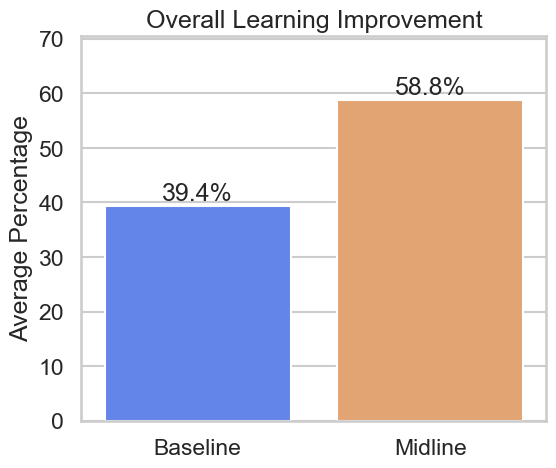

In [160]:
# Overall Learning Improvement

overall_only = pd.DataFrame({
    'Stage': ['Baseline', 'Midline'],
    'Percentage': [
        baseline_df['Overall_%'].mean(),
        midline_df['Overall_%'].mean()
    ]
}).round(1)

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=overall_only,
    x='Stage',
    y='Percentage',
    hue='Stage',
    palette=['#4d79ff', '#f4a261'],
    legend=False
)

plt.ylim(0, overall_only['Percentage'].max() * 1.2)

for i, v in enumerate(overall_only['Percentage']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Overall Learning Improvement")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.show()

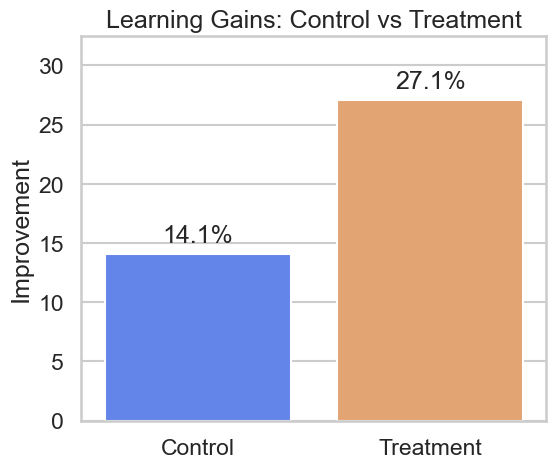

In [173]:
# Learning Gains: Control vs Treatment

baseline_group = baseline_df[baseline_df['Group'].isin(['Control', 'Treatment'])]
midline_group = midline_df[midline_df['Group'].isin(['Control', 'Treatment'])]

baseline_mean = baseline_group.groupby('Group')['Overall_Score'].mean()
midline_mean = midline_group.groupby('Group')['Overall_Score'].mean()

overall_gain_pct = pd.DataFrame({
    'Group': ['Control', 'Treatment'],
    'Improvement': [
        ((midline_mean['Control'] - baseline_mean['Control']) / 80) * 100,
        ((midline_mean['Treatment'] - baseline_mean['Treatment']) / 80) * 100
    ]
}).round(1)

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=overall_gain_pct,
    x='Group',
    y='Improvement',
    hue='Group',
    palette={'Control':'#4d79ff','Treatment':'#f4a261'},
    legend=False
)

plt.ylim(0, overall_gain_pct['Improvement'].max() * 1.2)

for i, v in enumerate(overall_gain_pct['Improvement']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Learning Gains: Control vs Treatment")
plt.ylabel("Improvement")
plt.xlabel("")
plt.show()

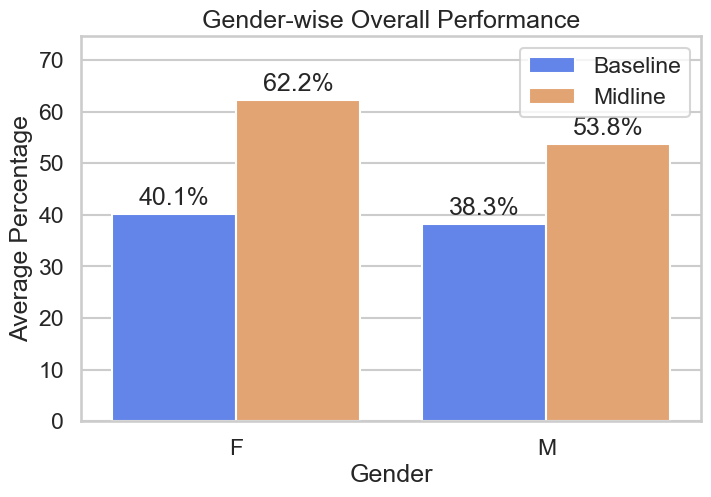

In [162]:
# Gender-wise Overall Performance

baseline_gender = (
    baseline_df[baseline_df['Gender_(M/F)'].isin(['M', 'F'])]
    .groupby('Gender_(M/F)', as_index=False)['Overall_%']
    .mean()
)
baseline_gender['Stage'] = 'Baseline'

midline_gender = (
    midline_df[midline_df['Gender_(M/F)'].isin(['M', 'F'])]
    .groupby('Gender_(M/F)', as_index=False)['Overall_%']
    .mean()
)
midline_gender['Stage'] = 'Midline'

gender_plot = pd.concat([baseline_gender, midline_gender], ignore_index=True).round(1)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=gender_plot,
    x='Gender_(M/F)',
    y='Overall_%',
    hue='Stage',
    palette=['#4d79ff', '#f4a261']
)

plt.ylim(0, gender_plot['Overall_%'].max() * 1.2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Gender-wise Overall Performance")
plt.ylabel("Average Percentage")
plt.xlabel("Gender")
plt.legend(title='')
plt.show()

<!-- Section 3: Impact Analysis Deep Dive (61 matched students) -->

# Section 3: Impact Analysis Deep Dive (61 matched students)

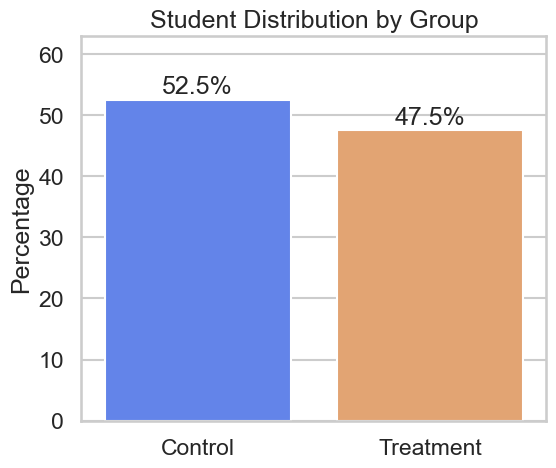

In [171]:
# Student Distribution by Group (Matched Students)

group_pct = (
    impact_df['Group_base']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)
group_pct.columns = ['Group', 'Percentage']

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=group_pct,
    x='Group',
    y='Percentage',
    hue='Group',
    palette={'Control':'#4d79ff','Treatment':'#f4a261'},
    legend=False
)

plt.ylim(0, group_pct['Percentage'].max() * 1.2)

for i, v in enumerate(group_pct['Percentage']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Student Distribution by Group")
plt.ylabel("Percentage")
plt.xlabel("")
plt.show()

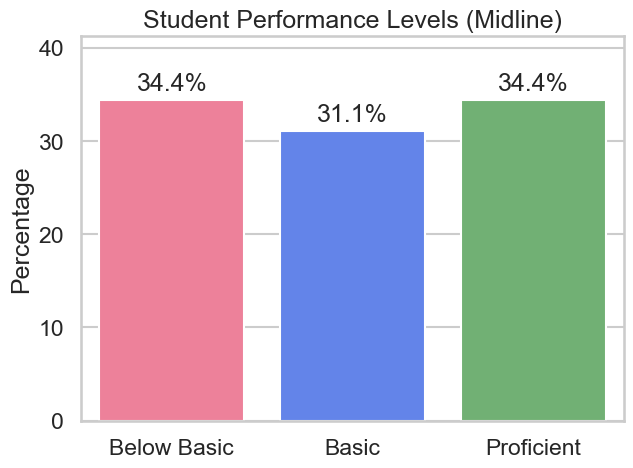

In [172]:
# Student Performance Levels (Matched Students)

impact_df['Overall_Tercile_mid'] = pd.qcut(
    impact_df['Overall_Score_mid'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

tercile_mapping = {
    'Low': 'Below Basic',
    'Medium': 'Basic',
    'High': 'Proficient'
}

impact_df['Tercile_Label_mid'] = impact_df['Overall_Tercile_mid'].astype(str).map(tercile_mapping)

tercile_pct = (
    impact_df['Tercile_Label_mid']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(desired_order)
    .round(1)
    .reset_index()
)
tercile_pct.columns = ['Performance_Level', 'Percentage']

plt.figure(figsize=(7,5))
ax = sns.barplot(
    data=tercile_pct,
    x='Performance_Level',
    y='Percentage',
    hue='Performance_Level',
    palette=['#ff6f91','#4d79ff','#66bb6a'],
    legend=False
)

plt.ylim(0, tercile_pct['Percentage'].max() * 1.2)

for i, v in enumerate(tercile_pct['Percentage']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Student Performance Levels (Midline)")
plt.ylabel("Percentage")
plt.xlabel("")
plt.show()

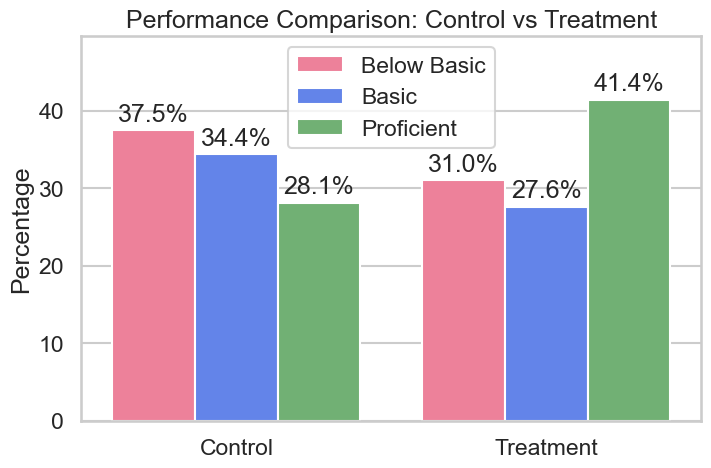

In [165]:
Performance Comparison: Control vs Treatment

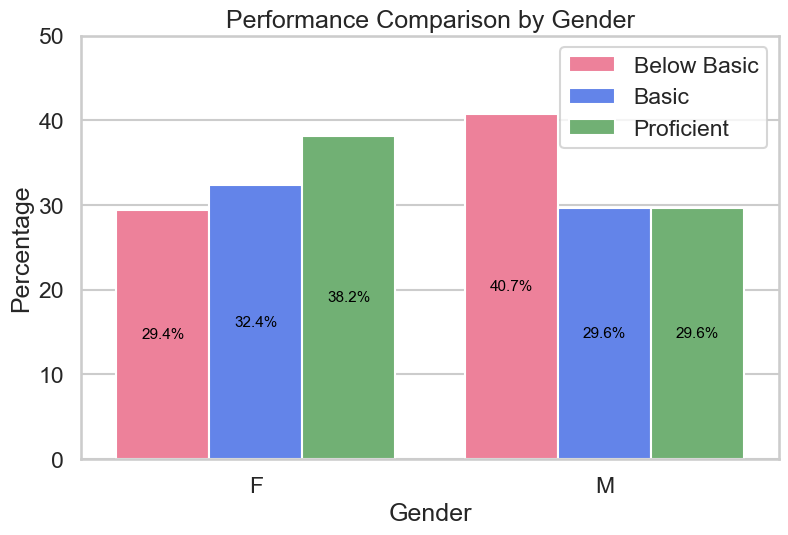

In [182]:
# Performance Comparison by Gender

gender_tercile = pd.crosstab(
    impact_df['Gender_(M/F)_base'],
    impact_df['Tercile_Label_mid'],
    normalize='index'
).mul(100)

gender_tercile = gender_tercile.reindex(columns=desired_order).round(1)
gender_tercile = gender_tercile.reset_index().melt(
    id_vars='Gender_(M/F)_base',
    var_name='Performance_Level',
    value_name='Percentage'
)

plt.figure(figsize=(9, 5.5))
ax = sns.barplot(
    data=gender_tercile,
    x='Gender_(M/F)_base',
    y='Percentage',
    hue='Performance_Level',
    palette=['#ff6f91','#4d79ff','#66bb6a']
)

plt.ylim(0, 50)

# labels in center of bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,                 # center inside bar
            f'{height:.1f}%',
            ha='center',
            va='center',
            fontsize=11,
            color='black'
        )

plt.title("Performance Comparison by Gender")
plt.ylabel("Percentage")
plt.xlabel("Gender")
plt.legend(title='')
plt.show()

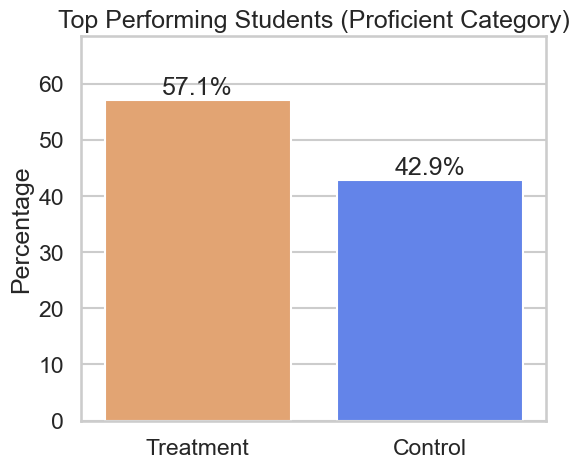

In [167]:
# Top Performing Students (Proficient Category)

high_perf = impact_df[impact_df['Tercile_Label_mid'] == 'Proficient']

high_pct = (
    high_perf['Group_base']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)
high_pct.columns = ['Group', 'Percentage']

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=high_pct,
    x='Group',
    y='Percentage',
    hue='Group',
    palette={'Control':'#4d79ff','Treatment':'#f4a261'},
    legend=False
)

plt.ylim(0, high_pct['Percentage'].max() * 1.2)

for i, v in enumerate(high_pct['Percentage']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Top Performing Students (Proficient Category)")
plt.ylabel("Percentage")
plt.xlabel("")
plt.show()

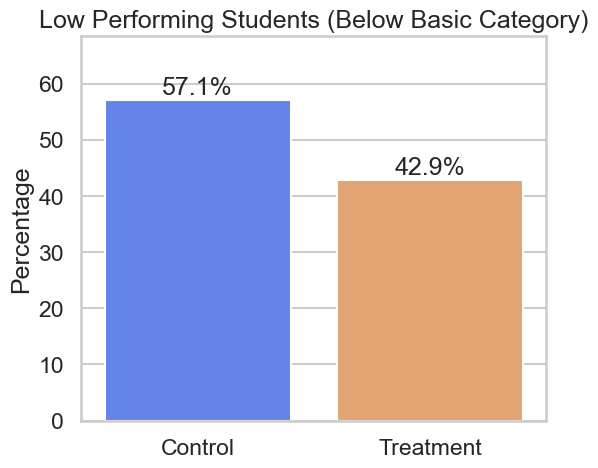

In [168]:
# Low Performing Students (Below Basic Category)

low_perf = impact_df[impact_df['Tercile_Label_mid'] == 'Below Basic']

low_pct = (
    low_perf['Group_base']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)
low_pct.columns = ['Group', 'Percentage']

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=low_pct,
    x='Group',
    y='Percentage',
    hue='Group',
    palette={'Control':'#4d79ff','Treatment':'#f4a261'},
    legend=False
)

plt.ylim(0, low_pct['Percentage'].max() * 1.2)

for i, v in enumerate(low_pct['Percentage']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Low Performing Students (Below Basic Category)")
plt.ylabel("Percentage")
plt.xlabel("")
plt.show()    

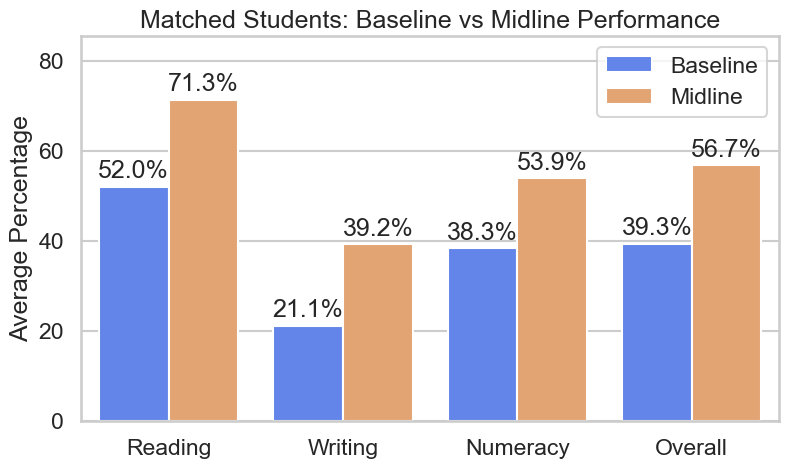

In [169]:
# Matched Students: Baseline vs Midline Performance

matched_subject_chart = pd.DataFrame({
    'Subject': ['Reading', 'Writing', 'Numeracy', 'Overall'],
    'Baseline': [52.0, 21.1, 38.3, 39.3],
    'Midline': [71.3, 39.2, 53.9, 56.7]
})

matched_subject_melted = matched_subject_chart.melt(
    id_vars='Subject',
    var_name='Stage',
    value_name='Percentage'
)

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=matched_subject_melted,
    x='Subject',
    y='Percentage',
    hue='Stage',
    palette=['#4d79ff', '#f4a261']
)

plt.ylim(0, matched_subject_melted['Percentage'].max() * 1.2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Matched Students: Baseline vs Midline Performance")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.legend(title='')
plt.show()

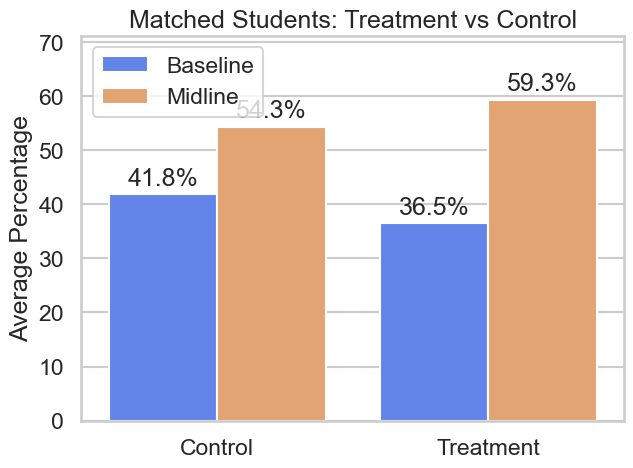

In [170]:
# Matched Students: Treatment vs Control

impact_group_chart = pd.DataFrame({
    'Group': ['Control', 'Treatment'],
    'Baseline': [41.8, 36.5],
    'Midline': [54.3, 59.3]
})

impact_group_melted = impact_group_chart.melt(
    id_vars='Group',
    var_name='Stage',
    value_name='Percentage'
)

plt.figure(figsize=(7,5))
ax = sns.barplot(
    data=impact_group_melted,
    x='Group',
    y='Percentage',
    hue='Stage',
    palette=['#4d79ff', '#f4a261']
)

plt.ylim(0, impact_group_melted['Percentage'].max() * 1.2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Matched Students: Treatment vs Control")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.legend(title='')
plt.show()

In [125]:
impact_df[impact_df['Tercile_Label_mid'] == 'Proficient']['Group_base'].value_counts(normalize=True) * 100

Group_base
Treatment    57.894737
Control      42.105263
Name: proportion, dtype: float64

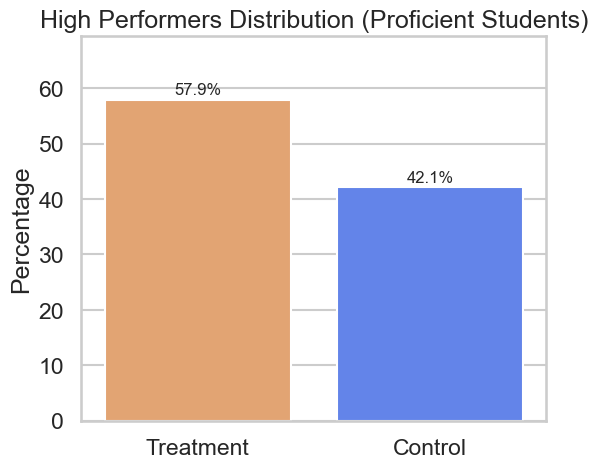

In [147]:
high_perf = impact_df[impact_df['Tercile_Label_mid'] == 'Proficient']

high_pct = (
    high_perf['Group_base']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)

high_pct.columns = ['Group', 'Percentage']

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=high_pct,
    x='Group',
    y='Percentage',
    hue='Group',
    palette=color_map,
    dodge=False,
    legend=False
)

plt.ylim(0, high_pct['Percentage'].max() * 1.20)

for i, v in enumerate(high_pct['Percentage']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=12)

plt.title('High Performers Distribution (Proficient Students)')
plt.ylabel('Percentage')
plt.xlabel('')
plt.xticks(rotation=0)
plt.show()

# Low Performers

In [126]:
impact_df[impact_df['Tercile_Label_mid'] == 'Below Basic']['Group_base'].value_counts(normalize=True) * 100

Group_base
Control      60.0
Treatment    40.0
Name: proportion, dtype: float64

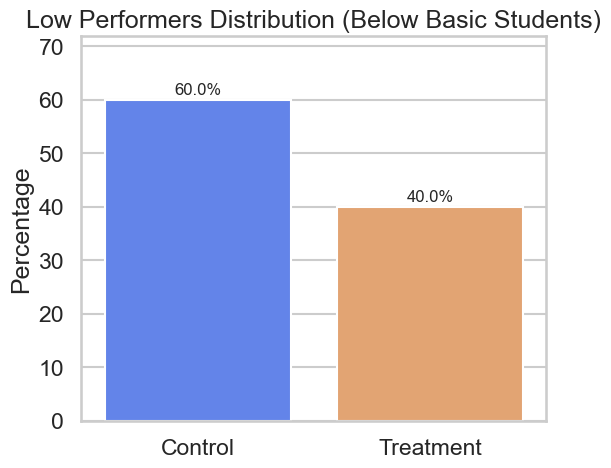

In [148]:
low_perf = impact_df[impact_df['Tercile_Label_mid'] == 'Below Basic']

low_pct = (
    low_perf['Group_base']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)

low_pct.columns = ['Group', 'Percentage']

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=low_pct,
    x='Group',
    y='Percentage',
    hue='Group',
    palette=color_map,
    dodge=False,
    legend=False
)

plt.ylim(0, low_pct['Percentage'].max() * 1.20)

for i, v in enumerate(low_pct['Percentage']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=12)

plt.title('Low Performers Distribution (Below Basic Students)')
plt.ylabel('Percentage')
plt.xlabel('')
plt.xticks(rotation=0)
plt.show()

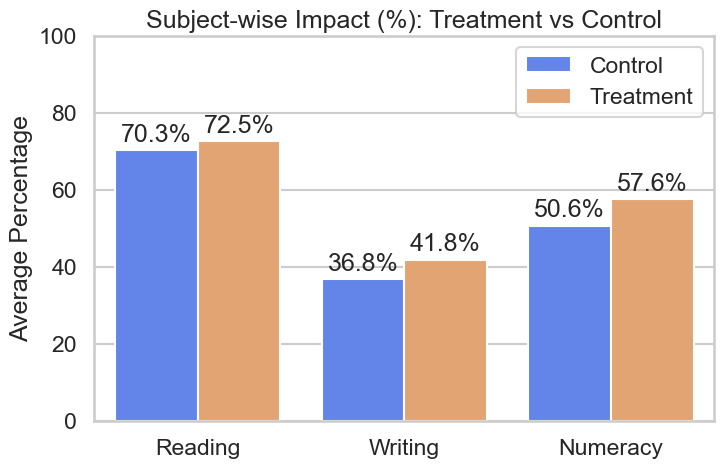

In [188]:
# Subject-wise Impact in Percentage (Matched Students)

impact_subject_pct = (
    impact_df[impact_df['Group_base'].isin(['Control', 'Treatment'])]
    .groupby('Group_base')[['Reading_%_mid', 'Writing_%_mid', 'Numeracy_%_mid']]
    .mean()
    .reset_index()
    .rename(columns={
        'Group_base': 'Group',
        'Reading_%_mid': 'Reading',
        'Writing_%_mid': 'Writing',
        'Numeracy_%_mid': 'Numeracy'
    })
)

impact_subject_pct_melted = impact_subject_pct.melt(
    id_vars='Group',
    var_name='Subject',
    value_name='Percentage'
)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=impact_subject_pct_melted,
    x='Subject',
    y='Percentage',
    hue='Group',
    palette=['#4d79ff', '#f4a261']
)

plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Subject-wise Impact : Treatment vs Control")
plt.ylabel("Average Percentage")
plt.xlabel("")
plt.legend(title='')
plt.show()

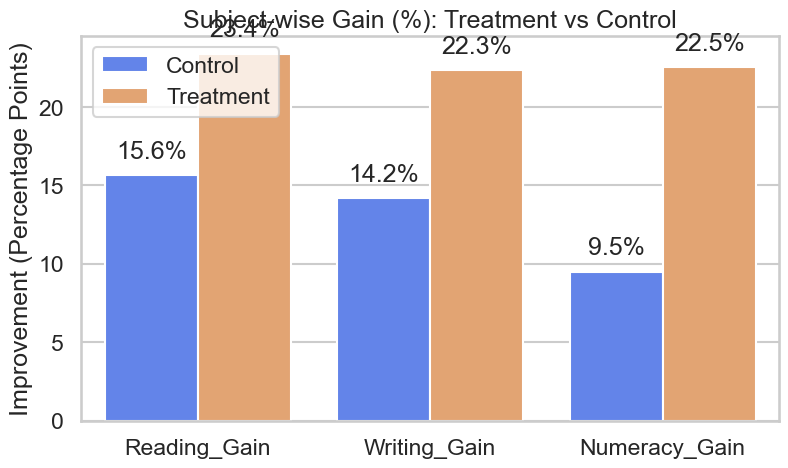

In [191]:
# Subject-wise Gain in Percentage (Midline % - Baseline %)

impact_subject_gain = (
    impact_df[impact_df['Group_base'].isin(['Control', 'Treatment'])]
    .groupby('Group_base')[[
        'Reading_%_base', 'Reading_%_mid',
        'Writing_%_base', 'Writing_%_mid',
        'Numeracy_%_base', 'Numeracy_%_mid'
    ]]
    .mean()
    .reset_index()
)

impact_subject_gain['Reading_Gain'] = impact_subject_gain['Reading_%_mid'] - impact_subject_gain['Reading_%_base']
impact_subject_gain['Writing_Gain'] = impact_subject_gain['Writing_%_mid'] - impact_subject_gain['Writing_%_base']
impact_subject_gain['Numeracy_Gain'] = impact_subject_gain['Numeracy_%_mid'] - impact_subject_gain['Numeracy_%_base']

impact_subject_gain = impact_subject_gain[['Group_base', 'Reading_Gain', 'Writing_Gain', 'Numeracy_Gain']].rename(columns={
    'Group_base': 'Group'
})

impact_subject_gain_melted = impact_subject_gain.melt(
    id_vars='Group',
    var_name='Subject',
    value_name='Gain_Percentage'
)

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=impact_subject_gain_melted,
    x='Subject',
    y='Gain_Percentage',
    hue='Group',
    palette=['#4d79ff', '#f4a261']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=9)

plt.title("Subject-wise Gain (%): Treatment vs Control")
plt.ylabel("Improvement (Percentage Points)")
plt.xlabel("")
plt.legend(title='')
plt.show()

In [192]:
# Subject-wise % Improvement (Impact Analysis)

subject_impact = (
    impact_df
    .groupby('Group_base')[[
        'Reading_%_base', 'Reading_%_mid',
        'Writing_%_base', 'Writing_%_mid',
        'Numeracy_%_base', 'Numeracy_%_mid'
    ]]
    .mean()
    .reset_index()
)

# Calculate improvement
subject_impact['Reading_Improvement'] = subject_impact['Reading_%_mid'] - subject_impact['Reading_%_base']
subject_impact['Writing_Improvement'] = subject_impact['Writing_%_mid'] - subject_impact['Writing_%_base']
subject_impact['Numeracy_Improvement'] = subject_impact['Numeracy_%_mid'] - subject_impact['Numeracy_%_base']

# Keep only needed columns
subject_impact = subject_impact[[
    'Group_base',
    'Reading_Improvement',
    'Writing_Improvement',
    'Numeracy_Improvement'
]]

subject_impact

,Group_base,Reading_Improvement,Writing_Improvement,Numeracy_Improvement
0,Control,15.625000,14.154412,9.461806
1,Treatment,23.371648,22.312373,22.509579


In [193]:
subject_impact_melted = subject_impact.melt(
    id_vars='Group_base',
    var_name='Subject',
    value_name='Improvement'
)

# Clean names
subject_impact_melted['Subject'] = subject_impact_melted['Subject'].str.replace('_Improvement', '')

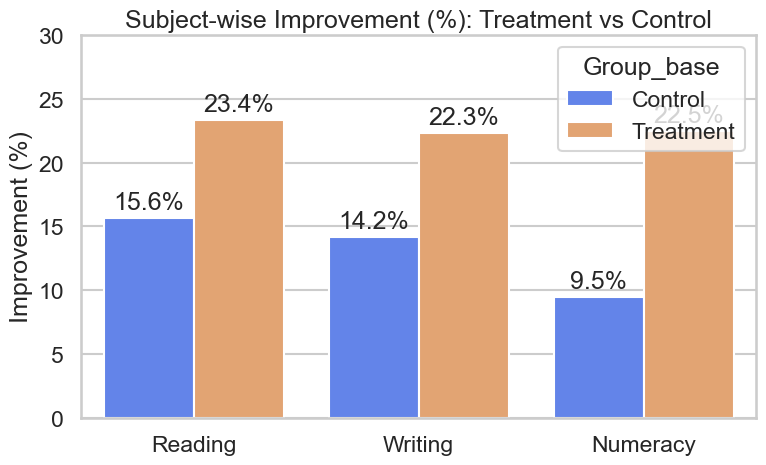

In [204]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=subject_impact_melted,
    x='Subject',
    y='Improvement',
    hue='Group_base',
    palette=['#4d79ff', '#f4a261']
)

# FIX 1: Clear axis
plt.ylabel("Improvement (%)")   # simpler
plt.xlabel("")

# FIX 2: Better limit
plt.ylim(0, 30)

# FIX 3: Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# FIX 4: Clean title
plt.title("Subject-wise Improvement (%): Treatment vs Control")

# FIX 5: Legend position
# plt.legend(title='', loc='upper right')
# plt.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.tight_layout()
plt.show()

In [116]:
midline_matched = impact_df.copy()  # your matched dataset

group_counts = midline_matched['Group_base'].value_counts()
print(group_counts)

Group_base
Control      32
Treatment    29
Name: count, dtype: int64


In [117]:
midline_matched = impact_df.copy()  # your matched dataset

group_counts = midline_matched['Group_base'].value_counts()
print(group_counts)

Group_base
Control      32
Treatment    29
Name: count, dtype: int64


In [118]:
tercile_counts = midline_matched['Tercile_Label_mid'].value_counts()
print(tercile_counts)

Tercile_Label_mid
Below Basic    25
Proficient     19
Basic          17
Name: count, dtype: int64


In [119]:
pd.crosstab(
    midline_matched['Group_base'],
    midline_matched['Tercile_Label_mid']
)

Tercile_Label_mid,Basic,Below Basic,Proficient
Group_base,,,
Control,9,15,8
Treatment,8,10,11


In [120]:
pd.crosstab(
    midline_matched['Group_base'],
    midline_matched['Tercile_Label_mid'],
    normalize='index'
) * 100

Tercile_Label_mid,Basic,Below Basic,Proficient
Group_base,,,
Control,28.125000,46.875000,25.000000
Treatment,27.586207,34.482759,37.931034


# Marks Analysis

In [79]:
# baseline_df.columns.tolist()

In [80]:
reading_cols = [
    'Hindi_Reading_1', 'Hindi_Reading_2', 'Hindi_Reading_3',
    'Hindi_Reading_4', 'Hindi_Reading_5', 'Hindi_Reading_6',
    'Hindi_Reading_7'
]

writing_cols = [
    'Hindi_Writing_1', 'Hindi_Writing_2',
    'Hindi_Writing_3', 'Hindi_Writing_4'
]

numeracy_cols = [
    'Numeracy_Q1', 'Numeracy_Q2', 'Numeracy_Q3', 'Numeracy_Q4',
    'Numeracy_Q5', 'Numeracy_Q6', 'Numeracy_Q7', 'Numeracy_Q8',
    'Numeracy_Q9', 'Numeracy_Q10', 'Numeracy_Q11'
]

all_question_cols = reading_cols + writing_cols + numeracy_cols

print(all_question_cols)
print([col for col in all_question_cols if col not in baseline_df.columns])
print([col for col in all_question_cols if col not in midline_df.columns])


['Hindi_Reading_1', 'Hindi_Reading_2', 'Hindi_Reading_3', 'Hindi_Reading_4', 'Hindi_Reading_5', 'Hindi_Reading_6', 'Hindi_Reading_7', 'Hindi_Writing_1', 'Hindi_Writing_2', 'Hindi_Writing_3', 'Hindi_Writing_4', 'Numeracy_Q1', 'Numeracy_Q2', 'Numeracy_Q3', 'Numeracy_Q4', 'Numeracy_Q5', 'Numeracy_Q6', 'Numeracy_Q7', 'Numeracy_Q8', 'Numeracy_Q9', 'Numeracy_Q10', 'Numeracy_Q11']
[]
[]


In [82]:
baseline_df[all_question_cols] = baseline_df[all_question_cols].apply(pd.to_numeric, errors='coerce')
midline_df[all_question_cols] = midline_df[all_question_cols].apply(pd.to_numeric, errors='coerce')

baseline_df['Total_Marks_80'] = baseline_df[all_question_cols].sum(axis=1)
baseline_df['Percentage_80'] = (baseline_df['Total_Marks_80'] / 80) * 100

midline_df['Total_Marks_80'] = midline_df[all_question_cols].sum(axis=1)
midline_df['Percentage_80'] = (midline_df['Total_Marks_80'] / 80) * 100

In [83]:
baseline_grade_pct = baseline_df.groupby('Grade', as_index=False)['Percentage_80'].mean().round(2)
baseline_grade_pct['Stage'] = 'Baseline'

midline_grade_pct = midline_df.groupby('Grade', as_index=False)['Percentage_80'].mean().round(2)
midline_grade_pct['Stage'] = 'Midline'

grade_compare_pct = pd.concat([baseline_grade_pct, midline_grade_pct], ignore_index=True)
print(grade_compare_pct)

  Grade  Percentage_80     Stage
0   2.0          27.38  Baseline
1   3.0          31.24  Baseline
2   4.0          41.65  Baseline
3   5.0          48.75  Baseline
4   1.0          37.81   Midline
5   2.0          44.72   Midline
6   3.0          53.75   Midline
7   4.0          67.07   Midline
8   5.0          64.25   Midline


In [84]:
# Clean Grade column in both datasets
for d in [baseline_df, midline_df]:
    d['Grade'] = d['Grade'].astype(str).str.strip()

    # remove common junk values
    d['Grade'] = d['Grade'].replace({
        'nan': np.nan,
        'NaN': np.nan,
        'None': np.nan,
        '': np.nan,
        '0': np.nan,
        '0.0': np.nan
    })

    # convert numeric-like grades properly
    d['Grade'] = pd.to_numeric(d['Grade'], errors='coerce')

    # keep only valid grades you want
    d.loc[~d['Grade'].isin([1, 2, 3, 4, 5]), 'Grade'] = np.nan

    # convert to integer then string for clean labels
    d['Grade'] = d['Grade'].astype('Int64').astype(str)

    # remove "<NA>" text created by astype(str)
    d['Grade'] = d['Grade'].replace('<NA>', np.nan)

In [85]:
question_max_marks = {
    # Reading
    'Hindi_Reading_1': 5,
    'Hindi_Reading_2': 4,
    'Hindi_Reading_3': 5,
    'Hindi_Reading_4': 4,
    'Hindi_Reading_5': 3,
    'Hindi_Reading_6': 3,
    'Hindi_Reading_7': 3,

    # Writing
    'Hindi_Writing_1': 6,
    'Hindi_Writing_2': 3,
    'Hindi_Writing_3': 4,
    'Hindi_Writing_4': 4,

    # Numeracy (FIXED)
    'Numeracy_Q1': 5,
    'Numeracy_Q2': 4,
    'Numeracy_Q3': 3,
    'Numeracy_Q4': 3,
    'Numeracy_Q5': 3,
    'Numeracy_Q6': 3,
    'Numeracy_Q7': 3,
    'Numeracy_Q8': 3,
    'Numeracy_Q9': 4,
    'Numeracy_Q10': 2,
    'Numeracy_Q11': 3
}

In [86]:
def plot_question_chart(df, q_col, q_max, title, stage_label):
    temp = df.copy()

    temp['Grade'] = pd.to_numeric(temp['Grade'], errors='coerce')

    temp = temp[
        temp['Group'].isin(['Treatment', 'Control']) &
        temp['Grade'].isin([2, 3, 4, 5])
    ].copy()

    temp[q_col] = pd.to_numeric(temp[q_col], errors='coerce')

    chart_df = (
        temp.groupby(['Group', 'Grade'], as_index=False)[q_col]
        .mean()
    )

    chart_df['Percentage'] = (chart_df[q_col] / q_max) * 100
    chart_df['Percentage'] = chart_df['Percentage'].clip(lower=0, upper=100)

    # Keep order
    group_order = ['Treatment', 'Control']
    grade_order = [2, 3, 4, 5]

    chart_df['Group'] = pd.Categorical(chart_df['Group'], categories=group_order, ordered=True)
    chart_df['Grade'] = pd.Categorical(chart_df['Grade'], categories=grade_order, ordered=True)
    chart_df = chart_df.sort_values(['Group', 'Grade']).reset_index(drop=True)

    # X positions
    x = list(range(len(chart_df)))

    colors = ['#4a80e0'] * 4 + ['#f39c12'] * 4

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    bars = ax.bar(x, chart_df['Percentage'], color=colors[:len(chart_df)])

    # value labels inside / above bars
    for i, v in enumerate(chart_df['Percentage']):
        if v >= 12:
            ax.text(i, v - 4, f"{v:.0f}%", ha='center', va='center', color='black', fontsize=11)
        else:
            ax.text(i, v + 2, f"{v:.0f}%", ha='center', va='bottom', color='black', fontsize=11)

    # first row: grades
    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Grade 2', 'Grade 3', 'Grade 4', 'Grade 5',
         'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5'],
        rotation=0,
        ha='center',
        fontsize=12,
        color='black',
        fontweight='bold'
    )

    # second row: group labels under bars

    ax.text(1.5, -0.25, 'Treatment', ha='center',
        transform=ax.get_xaxis_transform(),
        fontsize=13, fontweight='bold', color='black')

    ax.text(6.5, -0.25, 'Control', ha='center',
        transform=ax.get_xaxis_transform(),
        fontsize=13, fontweight='bold', color='black')
    

    plt.title(f"{stage_label} test score on {title}", fontsize=18)
    plt.ylim(0, 100)
    plt.ylabel("")
    plt.xlabel("")
    plt.yticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])

    # extra bottom space for second-row labels
    plt.subplots_adjust(bottom=0.30)

    plt.show()

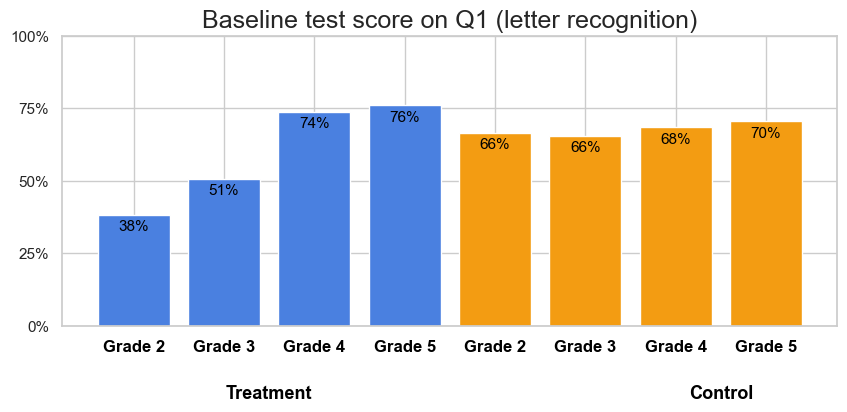

In [32]:
plot_question_chart(
    df=baseline_df,
    q_col='Hindi_Reading_1',
    q_max=5,
    title='Q1 (letter recognition)',
    stage_label='Baseline'
)

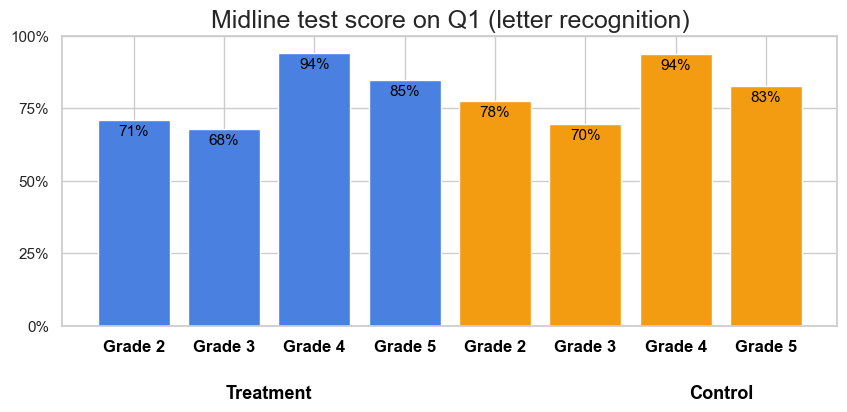

In [33]:
plot_question_chart(
    df=midline_df,
    q_col='Hindi_Reading_1',
    q_max=5,
    title='Q1 (letter recognition)',
    stage_label='Midline'
)

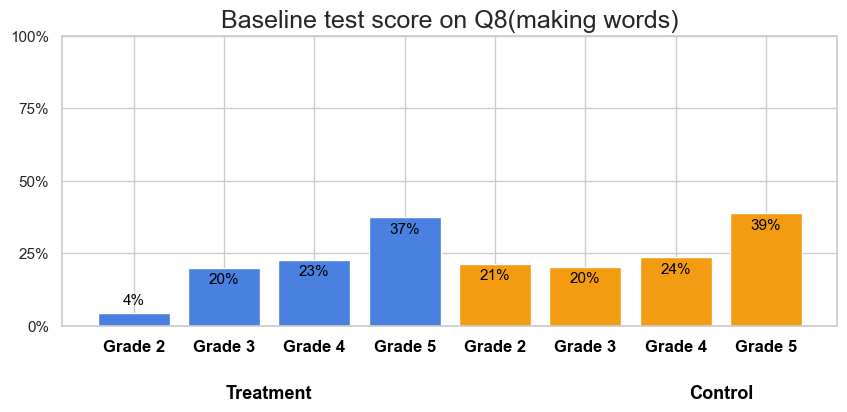

In [34]:
plot_question_chart(
    df=baseline_df,
    q_col='Hindi_Writing_3',
    q_max=5,
    title='Q8(making words)',
    stage_label='Baseline'
)

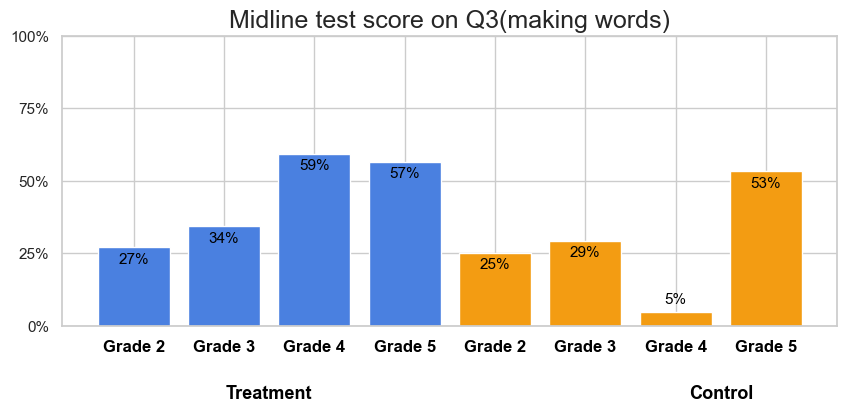

In [35]:
plot_question_chart(
    df=midline_df,
    q_col='Hindi_Writing_3',
    q_max=5,
    title='Q3(making words)',
    stage_label='Midline'
)

# 'Hindi_Writing_1': 6, -- Q8

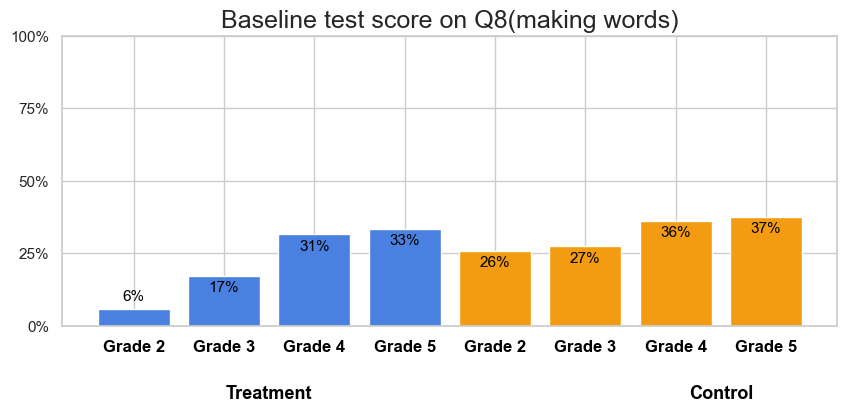

In [36]:
plot_question_chart(
    df=baseline_df,
    q_col='Hindi_Writing_1',
    q_max=6,
    title='Q8(making words)',
    stage_label='Baseline'
)

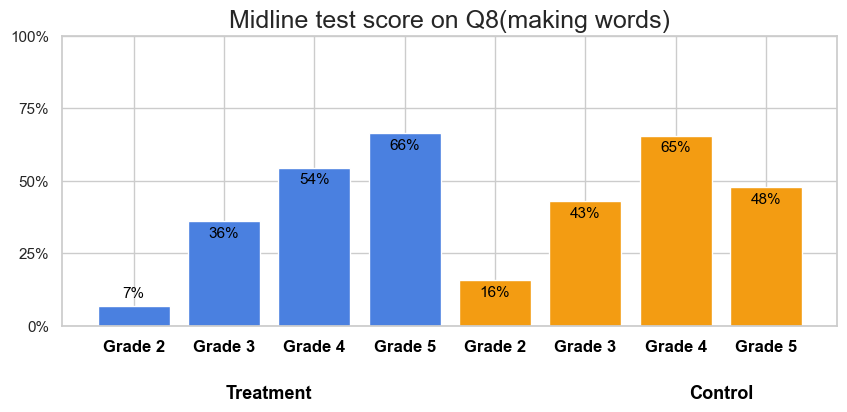

In [37]:
# 'Hindi_Writing_1': 6, -- Q8


plot_question_chart(
    df=midline_df,
    q_col='Hindi_Writing_1',
    q_max=6,
    title='Q8(making words)',
    stage_label='Midline'
)

# 'Numeracy_Q1': 5, - Q12

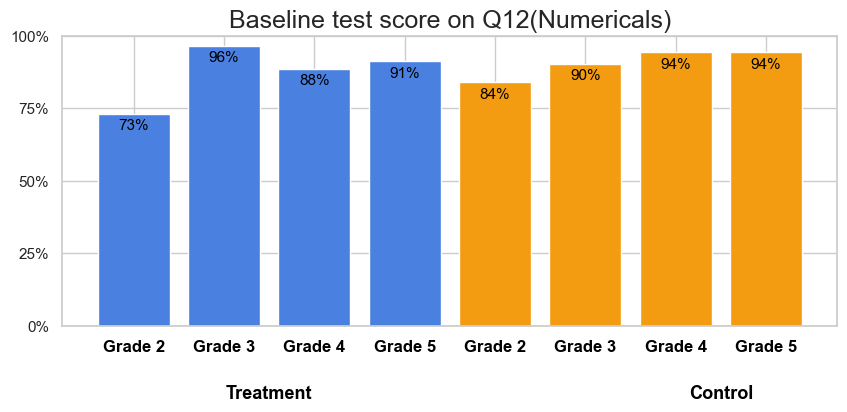

In [38]:
plot_question_chart(
    df=baseline_df,
    q_col='Numeracy_Q1',
    q_max=5,
    title='Q12(Numericals)',
    stage_label='Baseline'
)

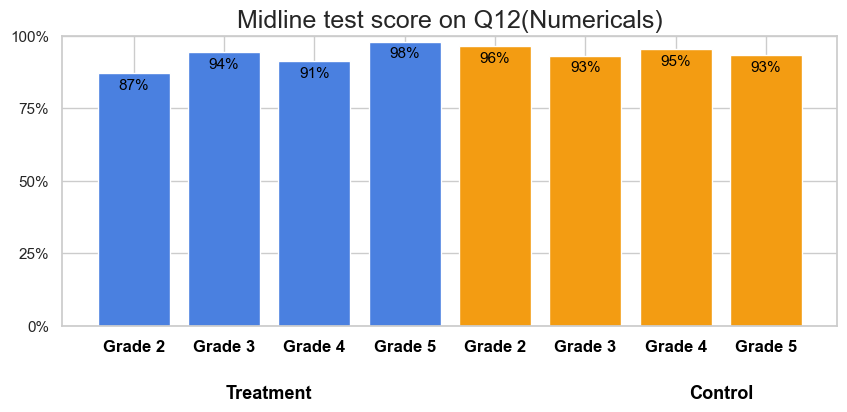

In [39]:
plot_question_chart(
    df=midline_df,
    q_col='Numeracy_Q1',
    q_max=5,
    title='Q12(Numericals)',
    stage_label='Midline'
)

# 'Numeracy_Q6': 3, Q-17

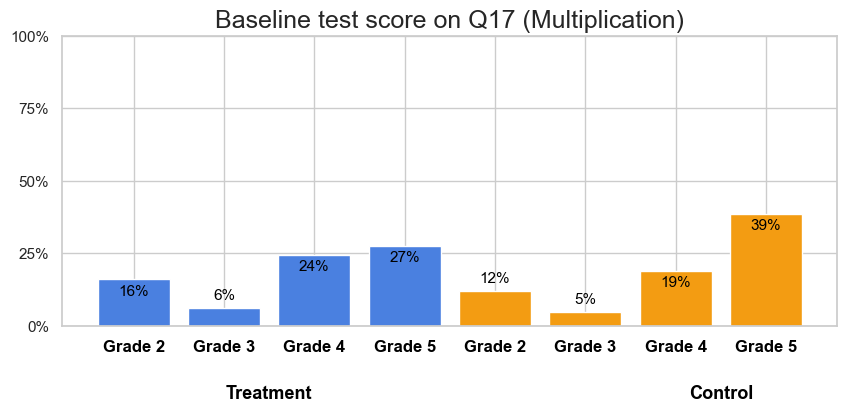

In [40]:
# # 'Numeracy_Q1': 3,

plot_question_chart(
    df=baseline_df,
    q_col='Numeracy_Q6',
    q_max=3,
    title='Q17 (Multiplication)',
    stage_label='Baseline'
)

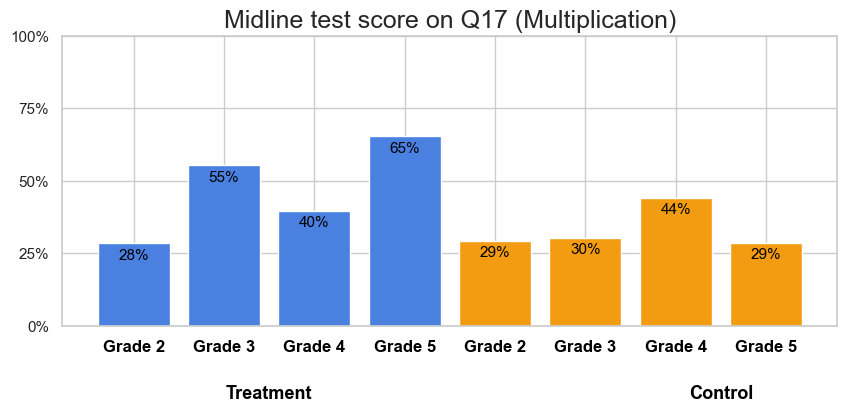

In [41]:
plot_question_chart(
    df=midline_df,
    q_col='Numeracy_Q6',
    q_max=3,
    title='Q17 (Multiplication)',
    stage_label='Midline'

)    

# 'Numeracy_Q9': 4, Q-20

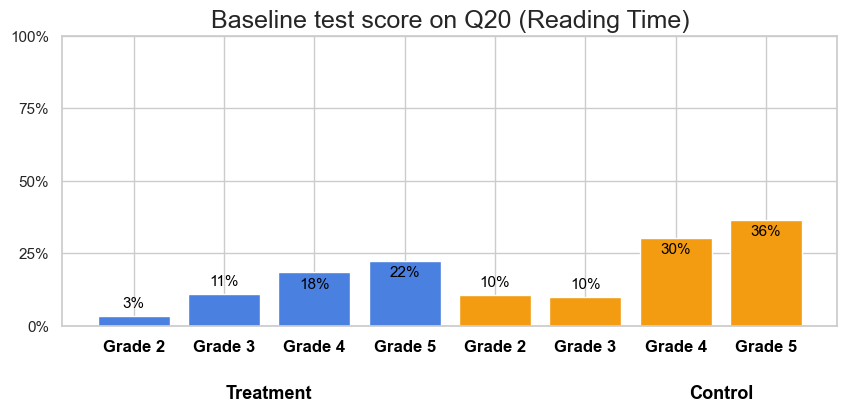

In [42]:
plot_question_chart(
    df=baseline_df,
    q_col='Numeracy_Q9',
    q_max=4,
    title='Q20 (Reading Time)',
    stage_label='Baseline'
)

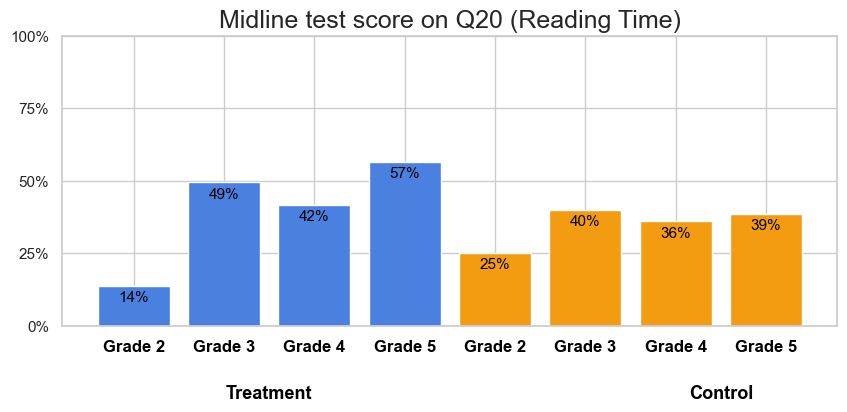

In [43]:
plot_question_chart(
    df=midline_df,
    q_col='Numeracy_Q9',
    q_max=4,
    title='Q20 (Reading Time)',
    stage_label='Midline'
)

In [44]:
q_col = 'Hindi_Writing_3'   # <-- change to your question

temp = midline_df[
    midline_df['Group'].isin(['Treatment', 'Control']) &
    midline_df['Grade'].isin([2, 3, 4, 5])
].copy()

temp[q_col] = pd.to_numeric(temp[q_col], errors='coerce')

# Student count per group & grade
count_check = temp.groupby(['Group', 'Grade'])[q_col].count().reset_index(name='student_count')

print(count_check)

Empty DataFrame
Columns: [Group, Grade, student_count]
Index: []


In [45]:
missing_check = temp.groupby(['Group', 'Grade'])[q_col].apply(lambda x: x.isna().sum()).reset_index(name='missing_count')

print(missing_check)

Empty DataFrame
Columns: [Group, Grade, missing_count]
Index: []


In [46]:
school_check = (
    temp.groupby(['Group', 'Grade', 'School_Name'])[q_col]
    .mean()
    .reset_index()
)

print(school_check.sort_values(['Group', 'Grade', q_col]))

Empty DataFrame
Columns: [Group, Grade, School_Name, Hindi_Writing_3]
Index: []


In [47]:
print(temp[q_col].max())

nan


In [48]:
baseline_scores = baseline_df['Overall_Score'].dropna()
midline_scores = midline_df['Overall_Score'].dropna()

mean1 = baseline_scores.mean()
mean2 = midline_scores.mean()

std1 = baseline_scores.std()
std2 = midline_scores.std()

n1 = len(baseline_scores)
n2 = len(midline_scores)

# pooled std
pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))

cohens_d = (mean2 - mean1) / pooled_std

print("Cohen's d:", round(cohens_d, 3))

Cohen's d: 0.921


In [183]:
# Student who scores higher

# Top students by Midline Overall Score
top_students_midline = (
    impact_df[
        ['Student_Name_base', 'School_Name_base', 'Grade_base', 'Group_base',
         'Overall_Score_mid', 'Overall_%_mid']
    ]
    .sort_values(by='Overall_Score_mid', ascending=False)
    .reset_index(drop=True)
)

top_students_midline.head(10)

,Student_Name_base,School_Name_base,Grade_base,Group_base,Overall_Score_mid,Overall_%_mid
0,adiba bi,govt. girls higher secondary school,5.0,Treatment,79,98.75
1,kartik yadav,govt. middle school karaiya haat,4.0,Control,70,87.50
2,radhika,govt. middle school hajipur,5.0,Control,69,86.25
3,nitin,govt. middle school saklon,5.0,Treatment,67,83.75
4,simran,govt. primary school tarwariya,3.0,Control,66,82.50
5,gomti vanshkar,govt. girls higher secondary school,5.0,Treatment,66,82.50
6,afifa,govt. girls higher secondary school,3.0,Treatment,65,81.25
7,divya,govt. middle school hajipur,5.0,Control,65,81.25
8,yash,pm shree high school bhauriya,2.0,Treatment,65,81.25
9,sana,govt. middle school dehri jageer,5.0,Control,62,77.50


In [184]:
# Top students (Matched) — Baseline

top_baseline = (
    impact_df[
        ['Student_Name_base', 'School_Name_base', 'Grade_base', 'Group_base',
         'Overall_Score_base', 'Overall_%_base']
    ]
    .sort_values(by='Overall_Score_base', ascending=False)
    .reset_index(drop=True)
)

top_baseline.head(10)

,Student_Name_base,School_Name_base,Grade_base,Group_base,Overall_Score_base,Overall_%_base
0,adiba bi,govt. girls higher secondary school,5.0,Treatment,77,96.25
1,gomti vanshkar,govt. girls higher secondary school,5.0,Treatment,59,73.75
2,ayan,govt. middle school dehri jageer,5.0,Control,57,71.25
3,nitin,govt. middle school saklon,5.0,Treatment,57,71.25
4,dilshan,govt. middle school dehri jageer,5.0,Control,56,70.00
5,saleha,govt. girls higher secondary school,4.0,Treatment,52,65.00
6,simran,govt. primary school tarwariya,3.0,Control,50,62.50
7,sandhya saini,govt. middle school hajipur,5.0,Control,50,62.50
8,sanjay,govt. primary school tarwariya,4.0,Control,47,58.75
9,komal,govt. primary school tarwariya,4.0,Control,47,58.75


In [185]:
top_midline = (
    impact_df[
        ['Student_Name_base', 'School_Name_base', 'Grade_base', 'Group_base',
         'Overall_Score_mid', 'Overall_%_mid']
    ]
    .sort_values(by='Overall_Score_mid', ascending=False)
    .reset_index(drop=True)
)

top_midline.head(10)

,Student_Name_base,School_Name_base,Grade_base,Group_base,Overall_Score_mid,Overall_%_mid
0,adiba bi,govt. girls higher secondary school,5.0,Treatment,79,98.75
1,kartik yadav,govt. middle school karaiya haat,4.0,Control,70,87.50
2,radhika,govt. middle school hajipur,5.0,Control,69,86.25
3,nitin,govt. middle school saklon,5.0,Treatment,67,83.75
4,simran,govt. primary school tarwariya,3.0,Control,66,82.50
5,gomti vanshkar,govt. girls higher secondary school,5.0,Treatment,66,82.50
6,afifa,govt. girls higher secondary school,3.0,Treatment,65,81.25
7,divya,govt. middle school hajipur,5.0,Control,65,81.25
8,yash,pm shree high school bhauriya,2.0,Treatment,65,81.25
9,sana,govt. middle school dehri jageer,5.0,Control,62,77.50


In [186]:
top_midline_clean = top_midline.rename(columns={
    'Student_Name_base': 'Student_Name',
    'School_Name_base': 'School_Name',
    'Grade_base': 'Grade',
    'Group_base': 'Group',
    'Overall_Score_mid': 'Midline_Score',
    'Overall_%_mid': 'Midline_%'
})

top_midline_clean.head(10)

,Student_Name,School_Name,Grade,Group,Midline_Score,Midline_%
0,adiba bi,govt. girls higher secondary school,5.0,Treatment,79,98.75
1,kartik yadav,govt. middle school karaiya haat,4.0,Control,70,87.50
2,radhika,govt. middle school hajipur,5.0,Control,69,86.25
3,nitin,govt. middle school saklon,5.0,Treatment,67,83.75
4,simran,govt. primary school tarwariya,3.0,Control,66,82.50
5,gomti vanshkar,govt. girls higher secondary school,5.0,Treatment,66,82.50
6,afifa,govt. girls higher secondary school,3.0,Treatment,65,81.25
7,divya,govt. middle school hajipur,5.0,Control,65,81.25
8,yash,pm shree high school bhauriya,2.0,Treatment,65,81.25
9,sana,govt. middle school dehri jageer,5.0,Control,62,77.50


In [187]:
# Top 5 students who improved the most

impact_df['Improvement'] = impact_df['Overall_%_mid'] - impact_df['Overall_%_base']

top_improved = (
    impact_df[
        ['Student_Name_base', 'School_Name_base', 'Grade_base', 'Group_base',
         'Overall_%_base', 'Overall_%_mid', 'Improvement']
    ]
    .sort_values(by='Improvement', ascending=False)
    .reset_index(drop=True)
)

top_improved.head(10)

,Student_Name_base,School_Name_base,Grade_base,Group_base,Overall_%_base,Overall_%_mid,Improvement
0,afifa,govt. girls higher secondary school,3.0,Treatment,11.25,81.25,70.00
1,vanshika,govt. girls higher secondary school,3.0,Treatment,25.00,75.00,50.00
2,yash,pm shree high school bhauriya,2.0,Treatment,32.50,81.25,48.75
3,kartik yadav,govt. middle school karaiya haat,4.0,Control,40.00,87.50,47.50
4,vaishnavi,govt. girls higher secondary school,3.0,Treatment,30.00,75.00,45.00
5,salman khan,govt. middle school hajipur,5.0,Control,32.50,77.50,45.00
6,divya,govt. middle school hajipur,5.0,Control,38.75,81.25,42.50
7,kartik,pm shree high school bhauriya,2.0,Treatment,36.25,76.25,40.00
8,rishika,pm shree high school bhauriya,5.0,Treatment,27.50,66.25,38.75
9,harsh,govt. middle school karaiya haat,3.0,Control,18.75,57.50,38.75
